# Project Background

This project aims to analyze customer behavior using the UK E-Commerce Dataset, which consists of transaction records from a retail company based in the United Kingdom. The dataset includes all online purchase transactions between December 1st, 2010 and December 9th, 2011.

Given the seasonal nature of the products offered, this analysis focuses particularly on the peak sales period from September to December 2011. The main goal of the analysis is to identify customer purchasing patterns, segment customers based on their purchasing characteristics, and provide insights that can help enhance customer retention strategies and improve the effectiveness of future marketing campaigns.

# Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
from operator import attrgetter
from matplotlib.colors import LinearSegmentedColormap

# Load Dataset

In [ ]:
data = pd.read_csv('/content/data.csv', encoding = 'unicode_escape')
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


# Get Basic Informations

## Info of the Data

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


The **InvoiceDate** column is currently stored as a string (object type), and it must be converted into a proper datetime format. This conversion is essential for enabling time-based analyses such as sales trends, seasonal behavior, and purchase period segmentation.

## Describe the Numerical Data

In [ ]:
data[['Quantity', 'UnitPrice']].describe()

,Quantity,UnitPrice
count,541909.000000,541909.000000
mean,9.552250,4.611114
std,218.081158,96.759853
min,-80995.000000,-11062.060000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,38970.000000


The presence of negative values in these fields is unusual in the context of standard sales transactions. These values may indicate order cancellations, product returns, or data entry errors. Additionally, extreme outliers were found: a maximum **Quantity** of 80,995 and a maximum **UnitPrice** of 38,970. These values fall far outside the expected range and should be further investigated to determine whether they should be cleaned or treated separately during analysis.

## Checking Null Values

In [ ]:
data.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


Null values in the **Description** column can affect product-level insights, while missing **CustomerID** values prevent us from attributing transactions to specific customers. These missing values should be handled carefully—whether by removal, imputation, or exclusion from certain parts of the analysis—to ensure accurate and meaningful results.

# Data Cleansing

## Convert InvoiceDate to datetime format

The **InvoiceDate** column was converted from an object type to a datetime format. This conversion is essential not only to match the actual content of the column, but also to enable time-based analysis, such as identifying sales trends, seasonal patterns, and period-based segmentation. It ensures consistency between the data type and the information being represented.

In [ ]:
# Convert InvoiceDate's datatype to datetime format
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])

## Filling Null Descriptions Using Mode of StockCode and Dropping Remaining Missing Values

To address null values in the **Description** column, a mode-based imputation strategy was applied using the corresponding **StockCode**. Since each **StockCode** uniquely represents a specific product, this approach helps maintain consistency across entries. If no valid mode is found for a given **StockCode**, the row is removed due to the inability to accurately identify the product.

In [ ]:
# Retrieve StockCodes from rows with null values in the 'Description' column
non_repeated_values = data[data['Description'].isnull()]['StockCode']

# Iterate through each StockCode to fill its corresponding null 'Description' with the mode
for i in non_repeated_values:
  mode_description = data[data['StockCode'] == i]['Description'].mode()

  if not mode_description.empty:
    # Fill the null 'Description' with the most frequent (mode) value
    data.loc[(data['StockCode'] == i) & (data['Description'].isnull()), 'Description'] = mode_description[0]

# Drop any remaining rows where 'Description' is still null
data.dropna(subset=['Description'], inplace=True)

## Drop Null Values in CustomerID Column

All rows containing null values in the **CustomerID** column were removed. This decision was made due to the absence of additional information that could help identify or impute the missing customer IDs. Given the importance of this column for customer behavior analysis, retaining these incomplete entries would hinder accurate segmentation and behavioral tracking.

In [ ]:
data.dropna(subset = ['CustomerID'], inplace =True)

In [ ]:
data.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


## Checking Duplicate Values & Handling Duplicate Values

Handling duplicate data is essential to ensure the accuracy of subsequent analysis. In this context, duplicates refer to entries with identical combinations of **CustomerID**, **InvoiceNo**, **StockCode**, **InvoiceDate**, and **UnitPrice**, which likely indicate repeated records of the same transaction.

To address this, the first step is to review the suspected duplicate entries. Then, the duplicate rows are merged by grouping them and summing the **Quantity** to reflect the actual total purchase amount for that transaction.

In [ ]:
data.duplicated().sum()

np.int64(5225)

In [ ]:
# Display duplicates for review before removal
dupes = data[data.duplicated(subset=['CustomerID', 'InvoiceNo', 'StockCode', 'InvoiceDate', 'UnitPrice'], keep=False)]
print(dupes.sort_values(by=['CustomerID', 'InvoiceDate']))

       InvoiceNo StockCode                        Description  Quantity  \
395371    571034     23245         SET OF 3 REGENCY CAKE TINS         4   
395372    571034     22423           REGENCY CAKESTAND 3 TIER         4   
395388    571034     23239  SET OF 4 KNICK KNACK TINS POPPIES         6   
395410    571034     23239  SET OF 4 KNICK KNACK TINS POPPIES         6   
395435    571034     22423           REGENCY CAKESTAND 3 TIER         6   
...          ...       ...                                ...       ...   
514105    579673     22662        LUNCH BAG DOLLY GIRL DESIGN         2   
514106    579673     20727            LUNCH BAG  BLACK SKULL.         2   
514107    579673     23206             LUNCH BAG APPLE DESIGN         2   
198740    554065    85040A    S/4 PINK FLOWER CANDLES IN BOWL        36   
198743    554065    85040A    S/4 PINK FLOWER CANDLES IN BOWL        12   

               InvoiceDate  UnitPrice  CustomerID         Country  
395371 2011-10-13 12:47:00     

In [ ]:
# Merge duplicate rows and sum the Quantity
data_cleaned = (
    data
    .groupby(['InvoiceNo', 'StockCode', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'Description'], as_index=False)
    .agg({'Quantity': 'sum'})
)

In [ ]:
data_cleaned.duplicated().sum()

np.int64(0)

## Handling Negative Values and Outliers in **Quantity** and **UnitPrice** Columns

Based on initial data exploration using the **.describe()** method, it was found that the **Quantity** and **UnitPrice** columns contain highly unusual minimum values: -80,995 and -11,062 respectively.

Since the primary objective of this analysis is to understand customer purchasing behavior—not product returns—all records with negative quantity values were excluded from the core analysis. This decision was made to avoid bias caused by return transactions and to ensure that the insights generated reflect actual purchasing behavior.

To detect and remove extreme outliers in the **Quantity** and **UnitPrice** columns, the Interquartile Range (IQR) method was applied. In this approach, values falling outside the range of Q1 - 1.5 × IQR and Q3 + 1.5 × IQR are considered outliers and were removed from the dataset.

This approach helps preserve data quality, reduce distortion in statistical results, and improve the reliability of visualizations and mean-based analysis.

### UnitPrice

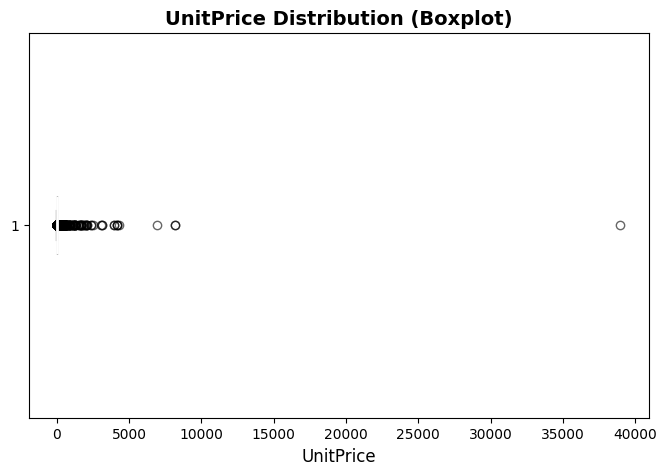

In [ ]:
# Create a boxplot for UnitPrice column
plt.figure(figsize=(8, 5))  # Adjust figure size for better readability
plt.boxplot(data_cleaned['UnitPrice'], vert=False, patch_artist=True,
            boxprops=dict(facecolor="darkcyan", color="black"),
            medianprops=dict(color="white", linewidth=2),
            whiskerprops=dict(color="black", linewidth=1.5),
            capprops=dict(color="black", linewidth=1.5),
            flierprops=dict(marker="o", color="red", alpha=0.6))

# Set title and labels
plt.title('UnitPrice Distribution (Boxplot)', fontsize=14, fontweight='bold')
plt.xlabel('UnitPrice', fontsize=12)

# Show the plot
plt.show()

In [ ]:
# Calculate the Interquartile Range (IQR) for UnitPrice
q1 = data_cleaned['UnitPrice'].quantile(.25)
q3 = data_cleaned['UnitPrice'].quantile(.75)
IQR = q3 - q1

# Define lower and upper bounds for outlier detection
lowerbound = q1 - 1.5 * IQR
upperbound = q3 + 1.5 * IQR

# Filter the dataset to remove outliers
data_cleaned=data_cleaned[(data_cleaned['UnitPrice'] > lowerbound) & (data_cleaned['UnitPrice'] < upperbound)]

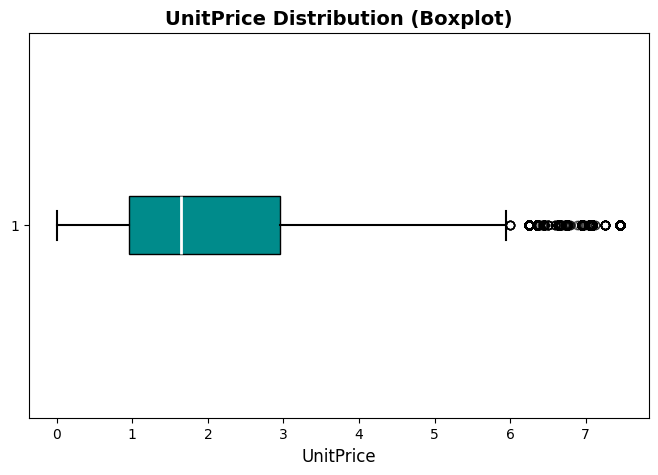

In [ ]:
# Create a boxplot for UnitPrice column
plt.figure(figsize=(8, 5))  # Adjust figure size for better readability
plt.boxplot(data_cleaned['UnitPrice'], vert=False, patch_artist=True,
            boxprops=dict(facecolor="darkcyan", color="black"),
            medianprops=dict(color="white", linewidth=2),
            whiskerprops=dict(color="black", linewidth=1.5),
            capprops=dict(color="black", linewidth=1.5),
            flierprops=dict(marker="o", color="red", alpha=0.6))

# Set title and labels
plt.title('UnitPrice Distribution (Boxplot)', fontsize=14, fontweight='bold')
plt.xlabel('UnitPrice', fontsize=12)

# Show the plot
plt.show()

### Quantity

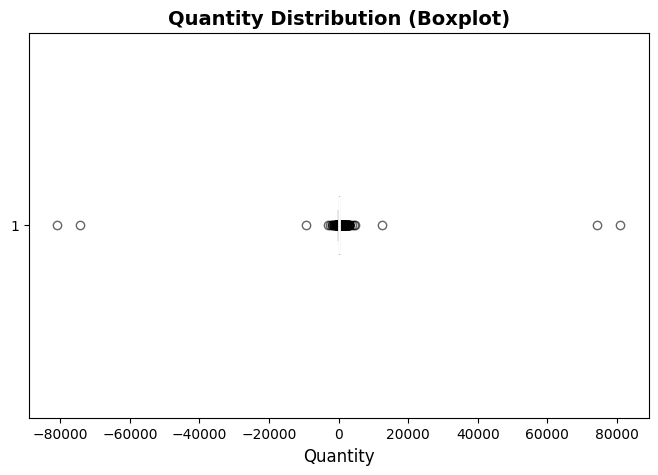

In [ ]:
# Create a boxplot for Quantity column
plt.figure(figsize=(8, 5))  # Adjust figure size for better readability
plt.boxplot(data_cleaned['Quantity'], vert=False, patch_artist=True,
            boxprops=dict(facecolor="darkcyan", color="black"),
            medianprops=dict(color="white", linewidth=2),
            whiskerprops=dict(color="black", linewidth=1.5),
            capprops=dict(color="black", linewidth=1.5),
            flierprops=dict(marker="o", color="red", alpha=0.6))

# Set title and labels
plt.title('Quantity Distribution (Boxplot)', fontsize=14, fontweight='bold')
plt.xlabel('Quantity', fontsize=12)

# Show the plot
plt.show()

In [ ]:
# Calculate the Interquartile Range (IQR) for Quantity
q1 = data_cleaned['Quantity'].quantile(0.25)
q3 = data_cleaned['Quantity'].quantile(0.75)
IQR = q3 - q1

# Define lower and upper bounds for outlier detection
lowerbound = q1 - 1.5 * IQR
upperbound = q3 + 1.5 * IQR

# Menghapus outlier (termasuk semua nilai negatif)
data_cleaned = data_cleaned[(data_cleaned['Quantity'] >= 0) & (data_cleaned['Quantity'] >= lowerbound) & (data_cleaned['Quantity'] <= upperbound)]

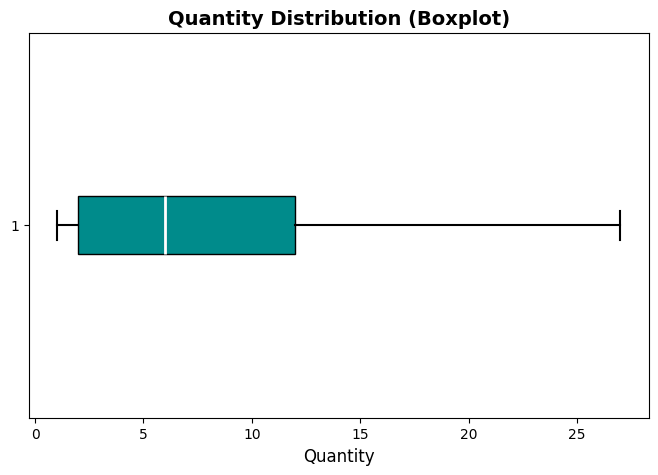

In [ ]:
# Create a boxplot for Quantity column
plt.figure(figsize=(8, 5))  # Adjust figure size for better readability
plt.boxplot(data_cleaned['Quantity'], vert=False, patch_artist=True,
            boxprops=dict(facecolor="darkcyan", color="black"),
            medianprops=dict(color="white", linewidth=2),
            whiskerprops=dict(color="black", linewidth=1.5),
            capprops=dict(color="black", linewidth=1.5),
            flierprops=dict(marker="o", color="red", alpha=0.6))

# Set title and labels
plt.title('Quantity Distribution (Boxplot)', fontsize=14, fontweight='bold')
plt.xlabel('Quantity', fontsize=12)

# Show the plot
plt.show()

In [ ]:
data_cleaned[['Quantity', 'UnitPrice']].describe()

,Quantity,UnitPrice
count,327903.000000,327903.000000
mean,7.684074,2.191585
std,6.780200,1.534084
min,1.000000,0.000000
25%,2.000000,1.250000
50%,6.000000,1.650000
75%,12.000000,2.950000
max,27.000000,7.460000


## Further Review: UnitPrice Value Equal to Zero

After handling negative values and outliers in the **Quantity** and **UnitPrice** columns, an additional issue was identified — the presence of entries where **UnitPrice** equals 0.

In the context of product sales, a price value of zero is considered invalid, as every product should have a defined price. Such entries likely result from data entry errors, internal system tests, or incomplete transactions.

In [ ]:
zero_price_items = data_cleaned[data_cleaned['UnitPrice'] == 0]
zero_price_items.head()

,InvoiceNo,StockCode,InvoiceDate,UnitPrice,CustomerID,Country,Description,Quantity
6622,537197,22841,2010-12-05 14:02:00,0.0,12647.0,Germany,ROUND CAKE TIN VINTAGE GREEN,1
21760,539263,22580,2010-12-16 14:36:00,0.0,16560.0,United Kingdom,ADVENT CALENDAR GINGHAM SACK,4
24529,539722,22423,2010-12-21 13:45:00,0.0,14911.0,EIRE,REGENCY CAKESTAND 3 TIER,10
28120,540372,22090,2011-01-06 16:41:00,0.0,13081.0,United Kingdom,PAPER BUNTING RETROSPOT,24
28146,540372,22553,2011-01-06 16:41:00,0.0,13081.0,United Kingdom,PLASTERS IN TIN SKULLS,24


In [ ]:
zero_price_items['Description'].value_counts().head(10)

,count
Description,
Manual,6
ROUND CAKE TIN VINTAGE GREEN,1
REGENCY CAKESTAND 3 TIER,1
PAPER BUNTING RETROSPOT,1
PLASTERS IN TIN SKULLS,1
ORGANISER WOOD ANTIQUE WHITE,1
FAIRY CAKES NOTEBOOK A6 SIZE,1
MINI CAKE STAND HANGING STRAWBERY,1
HEART GARLAND RUSTIC PADDED,1


## Analysis of Invoices Containing Both Free and Paid Items

This script is designed to identify mixed invoices — invoices that contain both free items (with UnitPrice = 0) and regularly priced items. This is useful to understand whether zero-priced items were given as bonuses within a larger transaction, rather than being recorded as standalone errors.

Here's what each step does:

1. **invoice_with_zero_price**: Extracts a list of invoice numbers (**InvoiceNo**) that contain at least one item with a unit price of zero. This is done by selecting the unique invoice numbers from the zero_price_items DataFrame.
2. **related_transactions**: Retrieves all transactions from the main dataset (**data_cleaned**) that are associated with the identified invoice numbers — meaning invoices that potentially contain both free and non-free items.
3. **invoice_mix**: Groups the related transactions by invoice number and calculates.
    - **zero_price_count**: the number of items in the invoice with **UnitPrice** = 0
    - **non_zero_price_count**: the number of items with **UnitPrice** > 0
4. **invoice_mix_filtered**: Filters the result to include only invoices that contain both:
    - At least one zero-priced item, and
    - At least one non-zero-priced item

The output of the script is a DataFrame named invoice_mix_filtered that contains a list of invoice numbers (InvoiceNo) along with two columns:
- zero_price_count: The number of items in the invoice that have a UnitPrice equal to 0.
- non_zero_price_count: The number of items in the same invoice that have a UnitPrice greater than 0.

Each row in this output represents a unique invoice that contains both free products (likely bonuses or manual entries) and paid products.

This output helps confirm that some zero-priced items are not recorded in isolation, but instead appear alongside regular purchases — suggesting they might have been part of promotional bundles, free gifts, or internal adjustments.

In [ ]:
# Retrieve all invoice numbers that include items with UnitPrice = 0
invoice_with_zero_price = zero_price_items['InvoiceNo'].unique()

# Extract all transactions related to those invoice numbers
related_transactions = data_cleaned[data_cleaned['InvoiceNo'].isin(invoice_with_zero_price)]

# Count the number of products with UnitPrice = 0 and UnitPrice > 0 per invoice
invoice_mix = (
    related_transactions
    .groupby('InvoiceNo')['UnitPrice']
    .agg(
        zero_price_count=lambda x: (x == 0).sum(),
        non_zero_price_count=lambda x: (x > 0).sum()
    )
    .reset_index()
)

# Filter invoices that contain both zero-priced and non-zero-priced products
invoice_mix_filtered = invoice_mix[
    (invoice_mix['zero_price_count'] > 0) & (invoice_mix['non_zero_price_count'] > 0)
]

invoice_mix_filtered.head()

,InvoiceNo,zero_price_count,non_zero_price_count
0,537197,1,12
1,539263,1,15
2,539722,1,20
3,540372,2,148
6,548318,1,3


In [ ]:
data_cleaned[data_cleaned['UnitPrice'] == 0][['InvoiceNo','Description']].value_counts()

InvoiceNo  Description                       
537197     ROUND CAKE TIN VINTAGE GREEN          1
539263     ADVENT CALENDAR GINGHAM SACK          1
539722     REGENCY CAKESTAND 3 TIER              1
540372     PAPER BUNTING RETROSPOT               1
           PLASTERS IN TIN SKULLS                1
541109     ORGANISER WOOD ANTIQUE WHITE          1
543599     FAIRY CAKES NOTEBOOK A6 SIZE          1
548318     MINI CAKE STAND  HANGING STRAWBERY    1
548871     HEART GARLAND RUSTIC PADDED           1
550188     CHILDS BREAKFAST SET CIRCUS PARADE    1
553000     PARTY BUNTING                         1
561284      OVAL WALL MIRROR DIAMANTE            1
561669     JAM MAKING SET WITH JARS              1
561916     Manual                                1
568158     PADS TO MATCH ALL CUSHIONS            1
568384     Manual                                1
569716     GLASS CLOCHE SMALL                    1
571035     Manual                                1
572893     PASTEL COLOUR HONEYCOMB FAN           1
574175     CHRISTMAS PUDDING TRINKET POT         1
574252     Manual                                1
574469     JUMBO BAG SPACEBOY DESIGN             1
574879     RED KITCHEN SCALES                    1
574920     CHILDREN'S APRON DOLLY GIRL           1
           MINI LIGHTS WOODLAND MUSHROOMS        1
575579     PAPER BUNTING VINTAGE PAISLEY         1
           SET OF 9 BLACK SKULL BALLOONS         1
577129     HANGING METAL HEART LANTERN           1
577168     Manual                                1
577314     SET OF 2 TRAYS HOME SWEET HOME        1
577696     Manual                                1
Name: count, dtype: int64

In [ ]:
# Count the number of items with price = 0 and price > 0 per invoice
invoice_check = (
    data
    .groupby('InvoiceNo')['UnitPrice']
    .agg(
        zero_price_count=lambda x: (x == 0).sum(),
        non_zero_price_count=lambda x: (x > 0).sum()
    )
    .reset_index()
)

# Filter invoices that contain only zero-priced products (no items with price > 0)
pure_zero_invoices = invoice_check[
    (invoice_check['zero_price_count'] > 0) & (invoice_check['non_zero_price_count'] == 0)
]

# Extract all transactions from those invoices
pure_zero_transactions = data[data['InvoiceNo'].isin(pure_zero_invoices['InvoiceNo'])]

In [ ]:
pure_zero_transactions.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
86789,543599,84535B,FAIRY CAKES NOTEBOOK A6 SIZE,16,2011-02-10 13:08:00,0.0,17560.0,United Kingdom
314745,564651,23270,SET OF 2 CERAMIC PAINTED HEARTS,96,2011-08-26 14:19:00,0.0,14646.0,Netherlands
314746,564651,23268,SET OF 2 CERAMIC CHRISTMAS REINDEER,192,2011-08-26 14:19:00,0.0,14646.0,Netherlands
314747,564651,22955,36 FOIL STAR CAKE CASES,144,2011-08-26 14:19:00,0.0,14646.0,Netherlands
314748,564651,21786,POLKADOT RAIN HAT,144,2011-08-26 14:19:00,0.0,14646.0,Netherlands


Further inspection revealed that some products with a **UnitPrice** of zero were bonus items provided as part of a larger purchase. In addition, several entries were found to be missing a **StockCode**, indicating incomplete records or manually entered data.

Some products were labeled as "Manual," suggesting non-automated input, while the remaining entries lacked sufficient information to be clearly identified.

## Add Columns that Needed

To enhance the analytical process and enable better segmentation and trend evaluation, several derived columns were added to the main dataset. These enrichments provide contextual depth to the raw data and streamline time-based analysis.


**1. Revenue Column**

Description: Total transaction value for each row.

Formula: Revenue = Quantity * UnitPrice

Purpose: Used to quantify the monetary value of each transaction. This metric forms the basis for revenue analysis, customer segmentation, and AOV (Average Order Value) calculations.


**2. MonthYear Column**

Description: A combination of month and year in the format 'MMM YYYY', e.g., 'Sep 2011'.

Formula: InvoiceDate.dt.to_period('M').dt.to_timestamp()

Purpose: Useful for plotting and labeling in time-series visualizations, improving clarity and consistency in reporting.


**3. Year, Month, and Quarter Columns**

Description: Extracted time components from the InvoiceDate column.

Formula:

Year: InvoiceDate.dt.year

Month: InvoiceDate.dt.month

Quarter: InvoiceDate.dt.quarter

Purpose: Enables time-based performance tracking (yearly, monthly, quarterly), trend discovery, and seasonality detection in customer and sales behavior.

### Revenue

In [ ]:
# Adding Revenue Column
data_cleaned['Revenue'] = data_cleaned['Quantity'] * data_cleaned['UnitPrice']

### Handling the Outliers for Revenue Column

After adding the *Revenue* column as a product of *UnitPrice* and *Quantity*, outlier detection was performed again, as the distribution of Revenue differs from its individual components. The IQR method was used to identify extreme revenue values that could potentially distort the analysis. Outlier transactions were removed to ensure the integrity of subsequent insights.

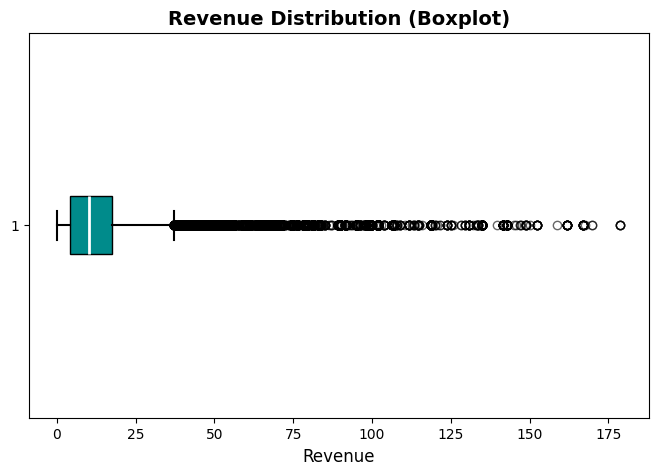

In [ ]:
# Create a boxplot for Revenue with customized color
plt.figure(figsize=(8, 5))  # Adjust figure size for better readability
plt.boxplot(data_cleaned['Revenue'], vert=False, patch_artist=True,
            boxprops=dict(facecolor="darkcyan", color="black"),
            medianprops=dict(color="white", linewidth=2),
            whiskerprops=dict(color="black", linewidth=1.5),
            capprops=dict(color="black", linewidth=1.5),
            flierprops=dict(marker="o", color="red", alpha=0.6))

# Set title and labels
plt.title('Revenue Distribution (Boxplot)', fontsize=14, fontweight='bold')
plt.xlabel('Revenue', fontsize=12)

# Show the plot
plt.show()

In [ ]:
# Calculate the Interquartile Range (IQR) for Revenue
q1 = data_cleaned['Revenue'].quantile(0.25)
q3 = data_cleaned['Revenue'].quantile(0.75)
IQR = q3 - q1

# Define lower and upper bounds for outlier detection
lowerbound = q1 - 1.5 * IQR
upperbound = q3 + 1.5 * IQR

# Filter dataset to remove extreme outliers
data_cleaned = data_cleaned[(data_cleaned['Revenue'] >= lowerbound) & (data_cleaned['Revenue'] <= upperbound)]

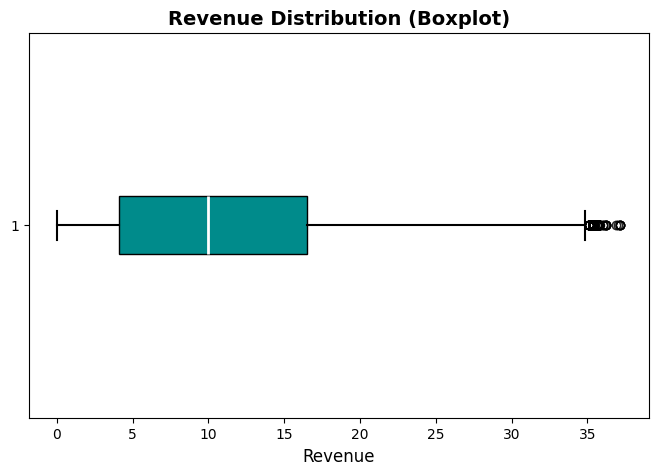

In [ ]:
# Create a boxplot for Revenue with customized color
plt.figure(figsize=(8, 5))  # Adjust figure size for better readability
plt.boxplot(data_cleaned['Revenue'], vert=False, patch_artist=True,
            boxprops=dict(facecolor="darkcyan", color="black"),
            medianprops=dict(color="white", linewidth=2),
            whiskerprops=dict(color="black", linewidth=1.5),
            capprops=dict(color="black", linewidth=1.5),
            flierprops=dict(marker="o", color="red", alpha=0.6))

# Set title and labels
plt.title('Revenue Distribution (Boxplot)', fontsize=14, fontweight='bold')
plt.xlabel('Revenue', fontsize=12)

# Show the plot
plt.show()

### year, month, quarter

In [ ]:
# Add additional columns to the dataset containing more detailed time-related information such as year, month, quarter which will be used for further analysis
data_cleaned['MonthYear'] = data_cleaned['InvoiceDate'].dt.to_period('M')

L = ['year', 'month', 'quarter']
data_cleaned = data_cleaned.join(pd.concat((getattr(data_cleaned['InvoiceDate'].dt, i).rename(i) for i in L), axis = 1))

In [ ]:
data_cleaned.head()

,InvoiceNo,StockCode,InvoiceDate,UnitPrice,CustomerID,Country,Description,Quantity,Revenue,MonthYear,year,month,quarter
0,536365,21730,2010-12-01 08:26:00,4.25,17850.0,United Kingdom,GLASS STAR FROSTED T-LIGHT HOLDER,6,25.50,2010-12,2010,12,4
2,536365,71053,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,WHITE METAL LANTERN,6,20.34,2010-12,2010,12,4
3,536365,84029E,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,RED WOOLLY HOTTIE WHITE HEART.,6,20.34,2010-12,2010,12,4
4,536365,84029G,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,KNITTED UNION FLAG HOT WATER BOTTLE,6,20.34,2010-12,2010,12,4
5,536365,84406B,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,CREAM CUPID HEARTS COAT HANGER,8,22.00,2010-12,2010,12,4


# Exploratory Data Analysis

Before conducting advanced analysis, an initial exploratory step was carried out to gain a comprehensive understanding of the dataset, including overall distribution and patterns. Several key metrics were selected to uncover initial insights related to business performance, customer behavior, and transaction characteristics.

Rationale Behind the Selected Metrics:

- Number of Orders and Products Sold: To evaluate the level of transaction activity and product demand over time.

- Revenue: As a primary indicator of sales performance.

- Revenue Growth: To identify peak periods and potential seasonal patterns.

- Geographic Distribution by Country: To assess regional contribution to total sales and identify high-potential markets.

Summary of Findings:

Through the initial exploration, various trends and insights were discovered. Each metric is analyzed individually, supported by visualizations to enhance clarity and understanding.

## Period Analysis

### Number of Orders

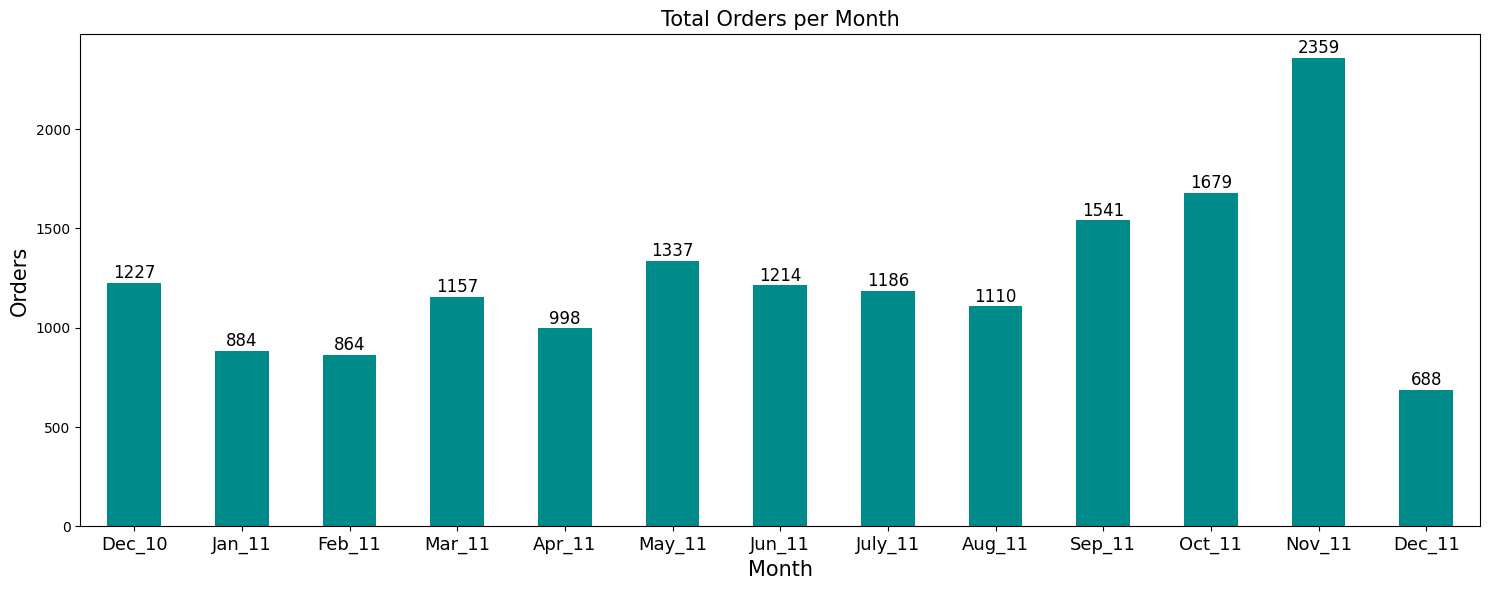

In [ ]:
# Count the number of unique orders per month
order_per_month = data_cleaned.groupby('InvoiceNo')['MonthYear'].unique().value_counts().sort_index()

# Plot bar chart
ax = order_per_month.plot(kind='bar', color='DarkCyan', figsize=(15, 6))

# Set label and title
ax.set_xlabel('Month', fontsize=15)
ax.set_ylabel('Orders', fontsize=15)
ax.set_title('Total Orders per Month', fontsize=15)
ax.set_xticklabels(('Dec_10','Jan_11','Feb_11','Mar_11','Apr_11','May_11','Jun_11','July_11','Aug_11','Sep_11','Oct_11','Nov_11','Dec_11'),
                   rotation='horizontal', fontsize=13)

# Annotate each bar with values
for i, value in enumerate(order_per_month):
    ax.text(i, value + 2, str(value), ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()

The number of orders fluctuated from January to August 2011, with no clear or consistent trend. This variability may be attributed to the seasonal nature of the products being sold, where order volume rises and falls unpredictably. Despite the fluctuations, no drastic drops were observed during this period.

A significant upward trend began in September and continued through November, suggesting the onset of a high-season period. November stood out with the highest number of orders, likely driven by pre-Christmas shopping activity.

The decline in December's order volume is not due to a real decrease in demand but rather due to incomplete data for that month. Based on the hypothesis that the surge in November was related to holiday shopping, it is reasonable to assume that December orders would have been even higher with complete data.

In [ ]:
# Ensure the index is sorted chronologically
order_per_month = order_per_month.sort_index()

# Calculate monthly total order growth in percentage and round to whole numbers
order_growth_per_month = (order_per_month.pct_change() * 100).fillna(0).round(0).astype(int)

# Combine into a single DataFrame
total_order_growth = pd.DataFrame({
    'Total_Orders': order_per_month,
    'Monthly_Growth_%': order_growth_per_month
})

In [ ]:
order_growth_per_month

,count
MonthYear,
[2010-12],0
[2011-01],-28
[2011-02],-2
[2011-03],34
[2011-04],-14
[2011-05],34
[2011-06],-9
[2011-07],-2
[2011-08],-6


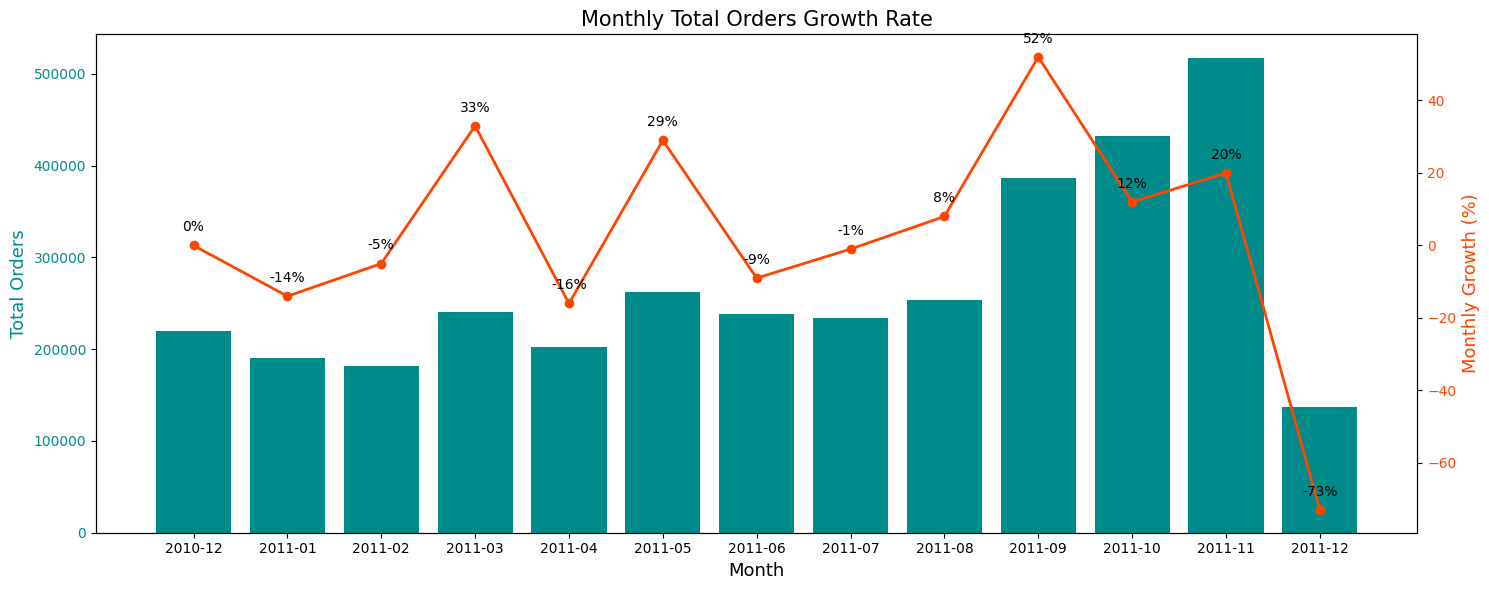

In [ ]:
fig, ax1 = plt.subplots(figsize=(15, 6))

# Bar chart for total orders
bars = ax1.bar(total_order_growth.index.astype(str), total_order_growth['Total_Orders'],
               color='DarkCyan', label='Total Orders')

ax1.set_xlabel('Month', fontsize=13)
ax1.set_ylabel('Total Orders', color='DarkCyan', fontsize=13)
ax1.tick_params(axis='y', labelcolor='DarkCyan')

# Line chart for monthly growth %
ax2 = ax1.twinx()
line = ax2.plot(total_order_growth.index.astype(str), total_order_growth['Monthly_Growth_%'],
                color='OrangeRed', marker='o', linewidth=2, label='Monthly Growth (%)')
ax2.set_ylabel('Monthly Growth (%)', color='OrangeRed', fontsize=13)
ax2.tick_params(axis='y', labelcolor='OrangeRed')

# Show only percentage labels on the line
for i, value in enumerate(total_order_growth['Monthly_Growth_%']):
    ax2.annotate(f'{value}%', (i, value + 2),
                 textcoords="offset points", xytext=(0, 5), ha='center', fontsize=10)

# Add title
plt.title('Monthly Total Orders Growth Rate', fontsize=15)
fig.tight_layout()
plt.show()

The chart displays total monthly orders and growth rates from December 2010 to December 2011. It shows significant fluctuations, with the highest spike in September (+52%) and peak order volume in November. A sharp drop of -73% in December may reflect incomplete data.

### Unit Sold Per Month

In [ ]:
unit_sold_per_month = data_cleaned.groupby('MonthYear')['Quantity'].sum()
unit_sold_per_month

,Quantity
MonthYear,
2010-12,130839
2011-01,123707
2011-02,116099
2011-03,157061
2011-04,135212
2011-05,167301
2011-06,156751
2011-07,164897
2011-08,171421


In [ ]:
# Ensure the index is sorted chronologically
order_per_month = order_per_month.sort_index()

# Calculate monthly unit sold growth in percentage and round to whole numbers
unit_growth_per_month = (unit_sold_per_month.pct_change() * 100).fillna(0).round(0).astype(int)

# Combine into a single DataFrame
unit_sales_growth = pd.DataFrame({
    'Units_Sold': unit_sold_per_month,
    'Monthly_Growth_%': unit_growth_per_month
})

In [ ]:
unit_growth_per_month

,Quantity
MonthYear,
2010-12,0
2011-01,-5
2011-02,-6
2011-03,35
2011-04,-14
2011-05,24
2011-06,-6
2011-07,5
2011-08,4


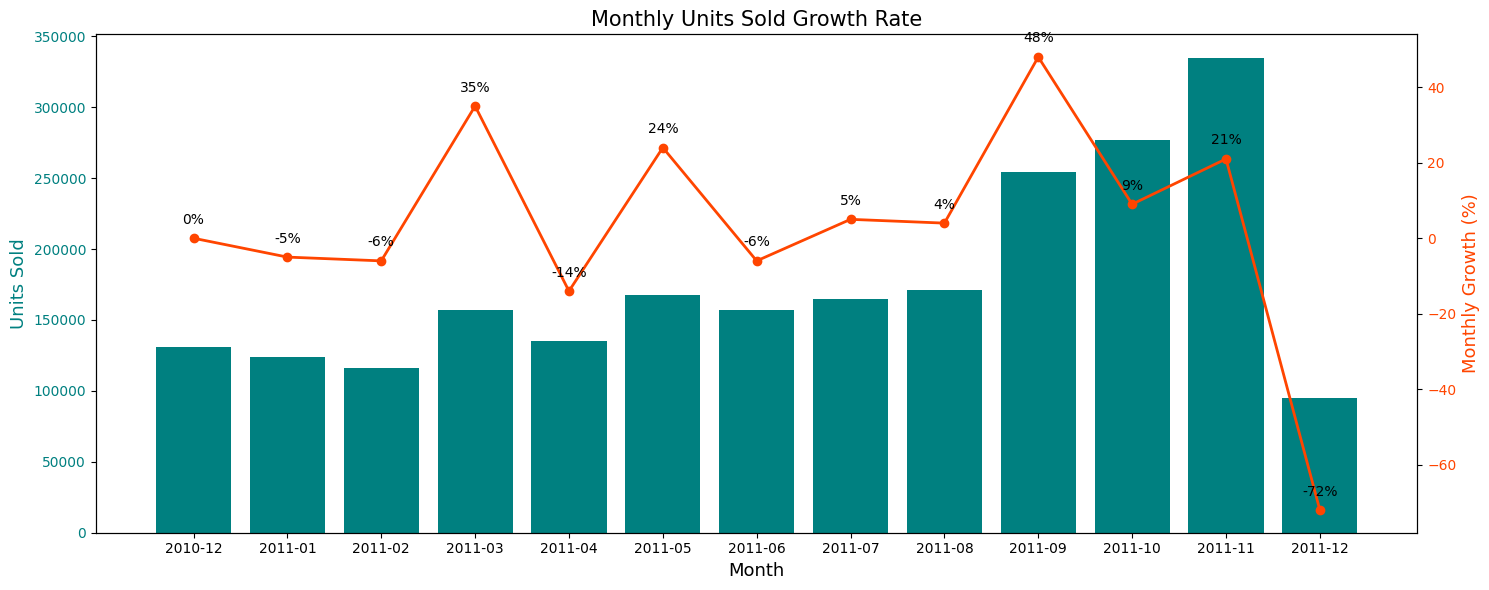

In [ ]:
# Create figure and axis
fig, ax1 = plt.subplots(figsize=(15, 6))

# Bar chart for units sold
bars = ax1.bar(unit_sales_growth.index.astype(str), unit_sales_growth['Units_Sold'],
               color='Teal', label='Units Sold')

# Set label and tick style for primary axis
ax1.set_xlabel('Month', fontsize=13)
ax1.set_ylabel('Units Sold', color='Teal', fontsize=13)
ax1.tick_params(axis='y', labelcolor='Teal')

# Line chart for monthly growth %
ax2 = ax1.twinx()
line = ax2.plot(unit_sales_growth.index.astype(str), unit_sales_growth['Monthly_Growth_%'],
                color='OrangeRed', marker='o', linewidth=2, label='Monthly Growth (%)')

# Set label and tick style for secondary axis
ax2.set_ylabel('Monthly Growth (%)', color='OrangeRed', fontsize=13)
ax2.tick_params(axis='y', labelcolor='OrangeRed')

# Add percentage labels to line chart only
for i, value in enumerate(unit_sales_growth['Monthly_Growth_%']):
    ax2.annotate(f'{value}%', (i, value + 2),
                 textcoords="offset points", xytext=(0, 5), ha='center', fontsize=10)

# Add title
plt.title('Monthly Units Sold Growth Rate', fontsize=15)
fig.tight_layout()
plt.show()

The chart displays monthly product units sold along with their growth rate from December 2010 to December 2011. The highest growth occurred in September 2011 (+48%), while the steepest decline was in December 2011 (-72%). The spikes toward the end of the year indicate a seasonal pattern, likely tied to holiday demand.

The discrepancy between the growth of total orders and units sold arises because each metric captures a different dimension of transaction behavior. Total orders represent the number of unique invoices generated each month, where typically one invoice corresponds to a single customer transaction.

On the other hand, units sold refer to the total quantity of items purchased, which means a single invoice can include multiple units of the same or different products. Therefore, an order can contain several units of a particular product.

This structural difference explains why the growth rate of total orders and units sold may not always align. For example, an increase in orders may indicate more customers are making purchases, but if the average quantity per transaction does not grow proportionally, then units sold may experience a slower growth rate compared to total orders.

### Revenue Per Month

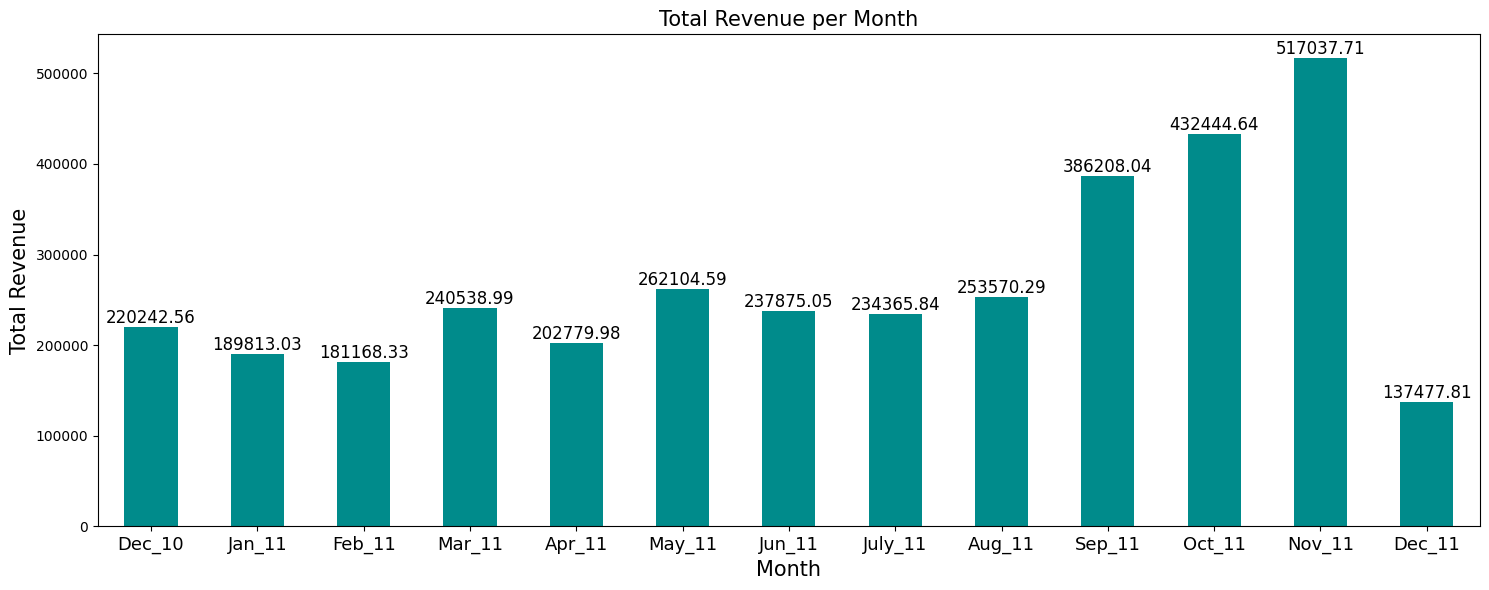

In [ ]:
# Calculate total revenue by month
order_per_month = data_cleaned.groupby('MonthYear')['Revenue'].sum()

# Plot bar chart
ax = order_per_month.plot(kind='bar', color='DarkCyan', figsize=(15, 6))

# Set label and title
ax.set_xlabel('Month', fontsize=15)
ax.set_ylabel('Total Revenue', fontsize=15)
ax.set_title('Total Revenue per Month', fontsize=15)
ax.set_xticklabels(('Dec_10','Jan_11','Feb_11','Mar_11','Apr_11','May_11','Jun_11','July_11','Aug_11','Sep_11','Oct_11','Nov_11','Dec_11'),
                   rotation='horizontal', fontsize=13)

# Annotate each bar with revenue values
for i, value in enumerate(order_per_month):
    ax.text(i, value + 2, str(round(value, 2)), ha='center', va='bottom', fontsize=12) # Added rounding for better display

plt.tight_layout()
plt.show()

Monthly revenue trends mirrored the order volume. Revenue began rising sharply in September and peaked in November, confirming the start of a high-revenue season in the last quarter of the year.

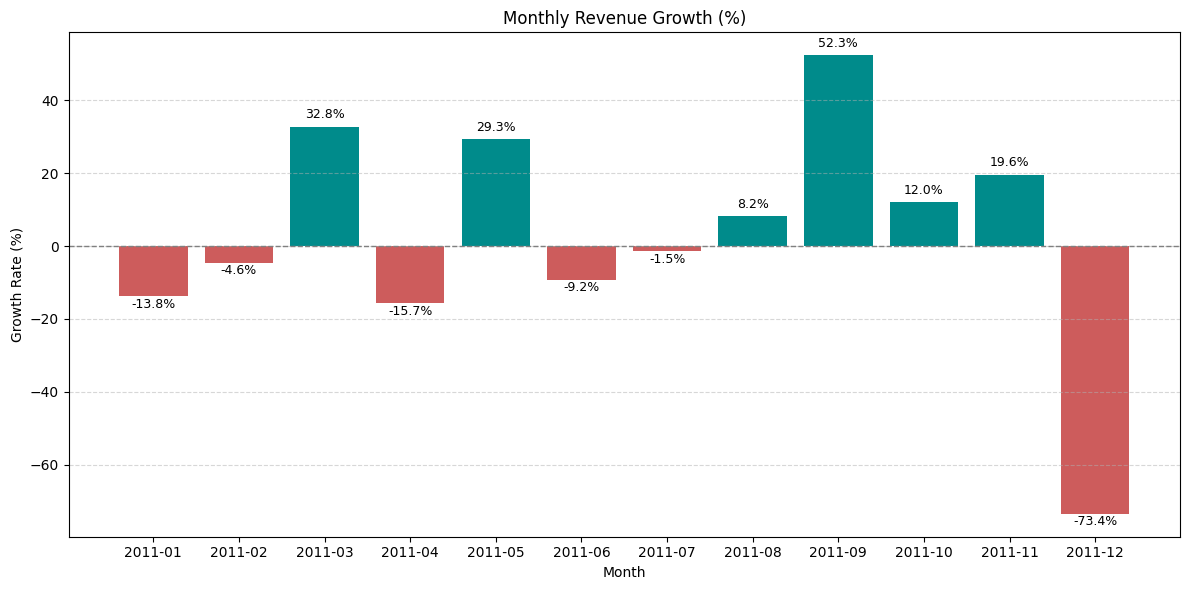

In [ ]:
# Calculate monthly total revenue
monthly_revenue = data_cleaned.groupby('MonthYear')['Revenue'].sum().reset_index()
monthly_revenue = monthly_revenue.sort_values('MonthYear')

# Calculate revenue growth percentage month-over-month
monthly_revenue['RevenueGrowth'] = monthly_revenue['Revenue'].pct_change() * 100

# Assign color for growth direction
monthly_revenue['Color'] = monthly_revenue['RevenueGrowth'].apply(
    lambda x: 'darkcyan' if x >= 0 else 'indianred'
)

# Plot bar chart with conditional coloring
plt.figure(figsize=(12, 6))
bars = plt.bar(
    monthly_revenue['MonthYear'].astype(str),
    monthly_revenue['RevenueGrowth'],
    color=monthly_revenue['Color']
)

# Annotate each bar with growth percentage
for index, row in monthly_revenue.iterrows():
    if pd.notnull(row['RevenueGrowth']):
        plt.text(
            x=index,
            y=row['RevenueGrowth'] + (1.5 if row['RevenueGrowth'] >= 0 else -4),
            s=f"{row['RevenueGrowth']:.1f}%",
            ha='center', va='bottom', fontsize=9
        )

# Add horizontal zero line
plt.axhline(0, color='gray', linestyle='--', linewidth=1)

# Format plot
plt.title('Monthly Revenue Growth (%)')
plt.xlabel('Month')
plt.ylabel('Growth Rate (%)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Revenue growth rate shows a clear spike in September, marking the start of significant sales momentum. Positive growth continued into October and November, followed by a sharp drop in December — again attributable to incomplete data.

### Revenue Per Quarter

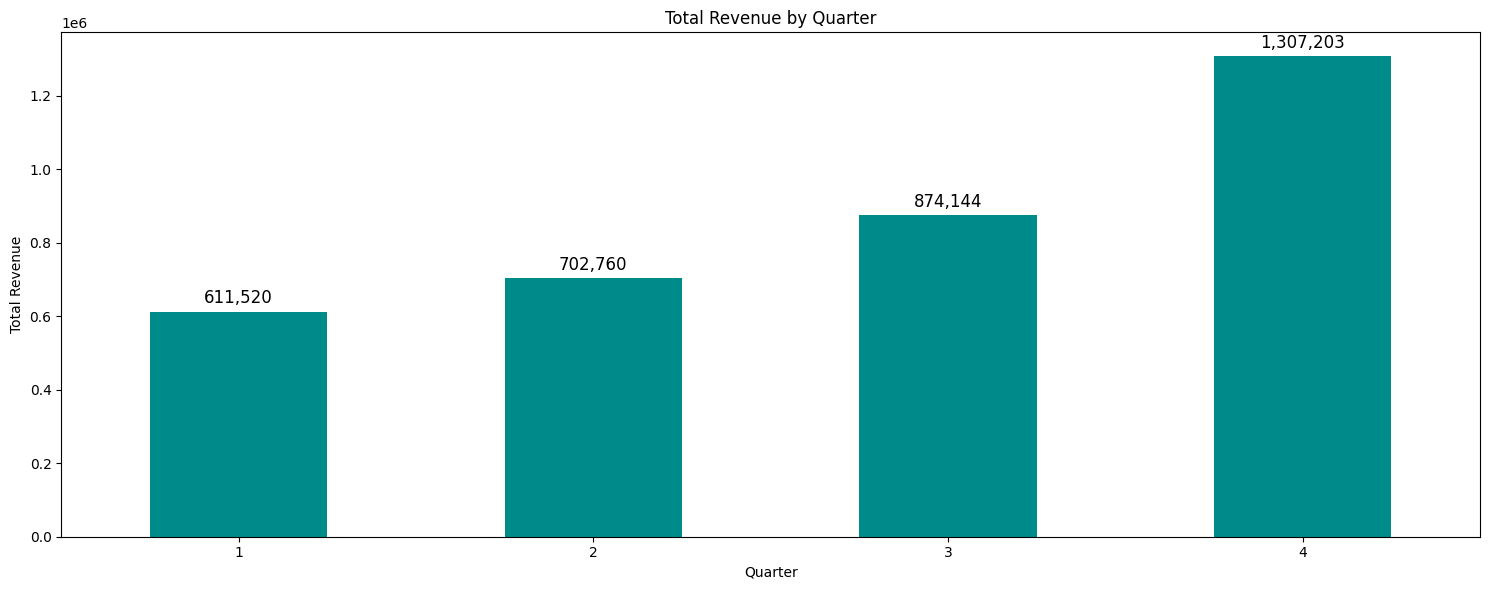

In [ ]:
# Calculate total revenue by quarter
quarterly_revenue = data_cleaned.groupby('quarter')['Revenue'].sum()

# Plot bar chart
ax = quarterly_revenue.plot(kind='bar', color='DarkCyan', figsize=(15, 6))

# Set label and title
plt.title('Total Revenue by Quarter')
plt.xlabel('Quarter')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)

# Annotate each bar with formatted revenue
for i, value in enumerate(quarterly_revenue):
    ax.text(i, value + (0.01 * quarterly_revenue.max()),  # beri sedikit jarak dari bar
            f'{value:,.0f}',  # format angka dengan ribuan
            ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()

Quarterly revenue analysis highlights the seasonal pattern even further. The fourth quarter (Q4) recorded the highest revenue among all quarters, reinforcing the hypothesis that both order volume and revenue surged towards the end of the year due to the Christmas season and year-end holidays.

## Analysis by Country

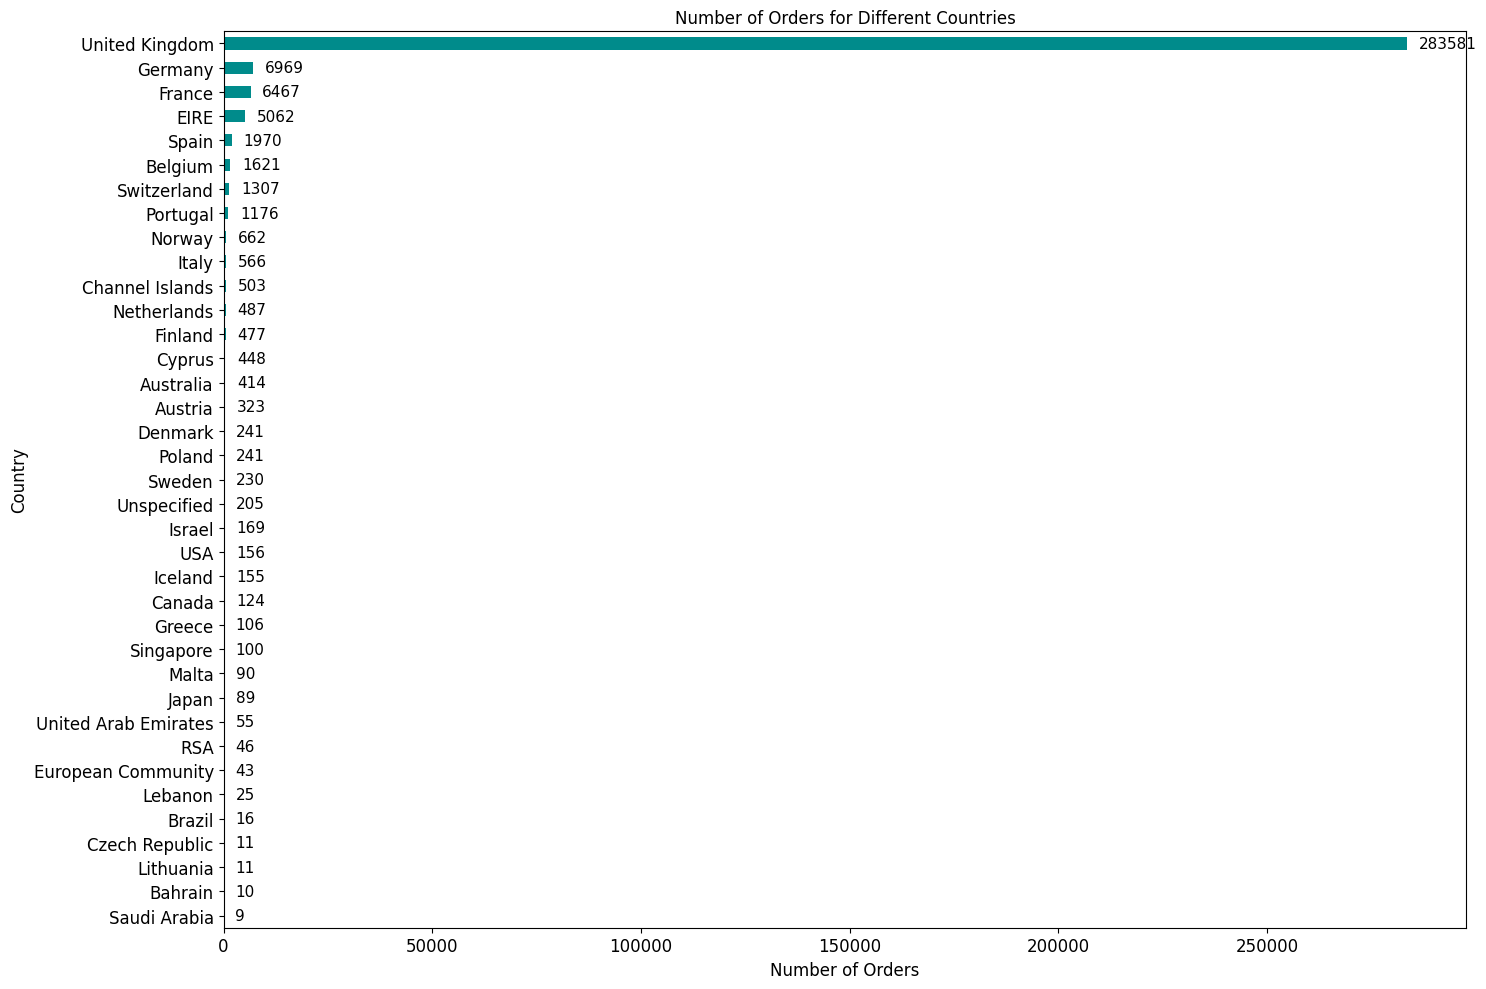

In [ ]:
# Count number of orders per country
group_country_orders = data_cleaned.groupby('Country')['InvoiceDate'].count().sort_values()

# Plot horizontal bar chart
fig, ax = plt.subplots(figsize=(15, 10))
group_country_orders.plot(kind='barh', fontsize=12, color='DarkCyan', ax=ax)

# Set label and title
ax.set_xlabel('Number of Orders', fontsize=12)
ax.set_ylabel('Country', fontsize=12)
ax.set_title('Number of Orders for Different Countries', fontsize=12)

# Annotate each bar with value
for i, value in enumerate(group_country_orders):
    ax.text(value + (0.01 * group_country_orders.max()), i, str(value), va='center', fontsize=11)

plt.tight_layout()
plt.show()

## Country Excluding United Kingdom

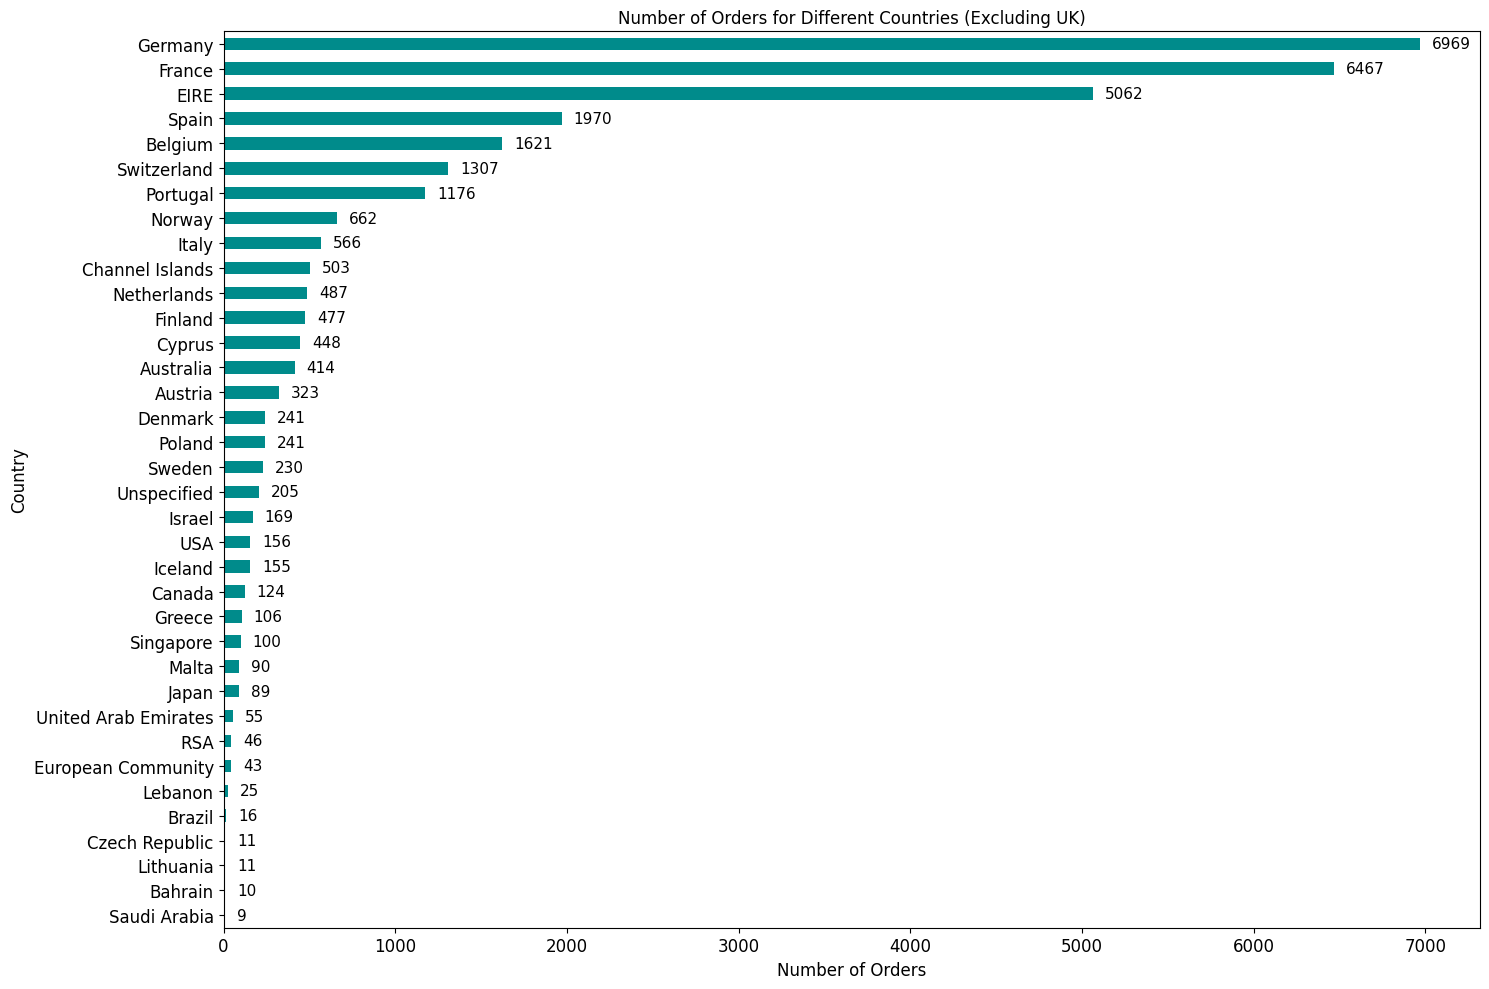

In [ ]:
# Remove UK from the data
group_country_orders_without_uk = group_country_orders.copy()
del group_country_orders_without_uk['United Kingdom']

# Plot horizontal bar chart
fig, ax = plt.subplots(figsize=(15, 10))
group_country_orders_without_uk.plot(kind='barh', fontsize=12, color='DarkCyan', ax=ax)

# Set label and title
ax.set_xlabel('Number of Orders', fontsize=12)
ax.set_ylabel('Country', fontsize=12)
ax.set_title('Number of Orders for Different Countries (Excluding UK)', fontsize=12)

# Annottate each bar with value
for i, value in enumerate(group_country_orders_without_uk):
    ax.text(value + (0.01 * group_country_orders_without_uk.max()), i, str(value), va='center', fontsize=11)

plt.tight_layout()
plt.show()

The chart shows that the United Kingdom accounts for the majority of the orders, which is expected since the e-commerce platform is based in the UK. With over 28,000 transactions, the UK clearly stands as the dominant market.

Beyond the UK, most orders originate from neighboring European countries. Countries such as Germany, France, and Ireland (EIRE) rank as the top three contributors among international customers.

When the UK is excluded from the analysis, Germany (6,969 orders), France (6,467), and EIRE (5,062) emerge as the leading sources of international orders, highlighting strong cross-border engagement within Western Europe.

Overall, the data indicates that Europe remains the core region for this e-commerce business, while order volume from non-European countries remains relatively low.

# Customer Behavior Analysis

The customer behavior analysis aims to understand how customers engage with the platform and contribute to revenue during the high-season period (September–November 2011). By analyzing segmentation and customer profiles, the business can design more targeted strategies for retention, acquisition, and campaign optimization.

This section includes the following analytical components:

**1. New vs. Existing Customers**

This analysis compares the contribution of new and returning customers in terms of revenue and order volume. It helps assess customer retention effectiveness and the potential value of new customer acquisition.

**2. RFM-Based Customer Segmentation**

The RFM (Recency, Frequency, Monetary) framework is used to segment customers based on their purchasing behavior. This allows the business to identify loyal customers, growth opportunities, and at-risk segments.

**3. Cohort Analysis (Customer Retention)**

Cohort analysis tracks the retention pattern of customers based on their first purchase month. It is valuable for measuring retention effectiveness and identifying when customers tend to churn.

**4. Top 5 Products by RFM Segment**

This analysis reveals the product preferences of different customer segments (Top, Potential, At Risk). It supports personalized marketing and product targeting strategies.

**5. Top 5 Products by Analysis Period**

This identifies the most popular products sold during the peak sales months. It is useful for inventory planning, product bundling, and promotional strategy development.

## New Customers and Existing Customers Comparison

This analysis compares the behavior and contribution of new customers versus returning (existing) customers during the analysis period.

Key metrics include:

- Proportion of each customer type by month,

- AOV per group,

- Contribution to total revenue.

This helps evaluate the platform’s customer acquisition efforts and retention strength.

In [ ]:
data_cleaned['InvoiceDate'].max()

Timestamp('2011-12-09 12:50:00')

In [ ]:
data_cleaned.head()

,InvoiceNo,StockCode,InvoiceDate,UnitPrice,CustomerID,Country,Description,Quantity,Revenue,MonthYear,year,month,quarter
0,536365,21730,2010-12-01 08:26:00,4.25,17850.0,United Kingdom,GLASS STAR FROSTED T-LIGHT HOLDER,6,25.50,2010-12,2010,12,4
2,536365,71053,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,WHITE METAL LANTERN,6,20.34,2010-12,2010,12,4
3,536365,84029E,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,RED WOOLLY HOTTIE WHITE HEART.,6,20.34,2010-12,2010,12,4
4,536365,84029G,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,KNITTED UNION FLAG HOT WATER BOTTLE,6,20.34,2010-12,2010,12,4
5,536365,84406B,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,CREAM CUPID HEARTS COAT HANGER,8,22.00,2010-12,2010,12,4


In [ ]:
# Calculate first transaction date per customer
first_purchase = data_cleaned.groupby('CustomerID')['InvoiceDate'].min().reset_index()
first_purchase.columns = ['CustomerID', 'FirstPurchaseDate']

In [ ]:
# Extract month of first purchase
first_purchase['FirstPurchaseMonth'] = first_purchase['FirstPurchaseDate'].dt.to_period('M')

In [ ]:
first_purchase.head()

,CustomerID,FirstPurchaseDate,FirstPurchaseMonth
0,12347.0,2010-12-07 14:57:00,2010-12
1,12348.0,2010-12-16 19:09:00,2010-12
2,12349.0,2011-11-21 09:51:00,2011-11
3,12350.0,2011-02-02 16:01:00,2011-02
4,12352.0,2011-02-16 12:33:00,2011-02


In [ ]:
# Add transaction month to main dataset
data_cleaned['TransMonth'] = data_cleaned['InvoiceDate'].dt.to_period('M')

In [ ]:
# Filter transactions for September to November 2011
seasonal_data = data_cleaned[
    (data_cleaned['InvoiceDate'].dt.year == 2011) &
    (data_cleaned['InvoiceDate'].dt.month.isin([9, 10, 11]))
].copy()

In [ ]:
# Merge to get each customer's first purchase date
seasonal_data = seasonal_data.merge(first_purchase, on='CustomerID', how='left')

In [ ]:
# Hitung Jumlah Pelanggan Baru Per Bulan
monthly_new_customers = seasonal_data.groupby('FirstPurchaseMonth')['CustomerID'].nunique().reset_index()
monthly_new_customers.columns = ['Month', 'NewCustomers']

In [ ]:
seasonal_data

,InvoiceNo,StockCode,InvoiceDate,UnitPrice,CustomerID,Country,Description,Quantity,Revenue,MonthYear,year,month,quarter,TransMonth,FirstPurchaseDate,FirstPurchaseMonth
0,565080,20677,2011-09-01 08:25:00,1.25,13509.0,United Kingdom,PINK POLKADOT BOWL,8,10.00,2011-09,2011,9,3,2011-09,2011-02-28 13:27:00,2011-02
1,565080,22128,2011-09-01 08:25:00,1.25,13509.0,United Kingdom,PARTY CONES CANDY ASSORTED,24,30.00,2011-09,2011,9,3,2011-09,2011-02-28 13:27:00,2011-02
2,565082,15060B,2011-09-01 09:15:00,3.75,13305.0,United Kingdom,FAIRY CAKE DESIGN UMBRELLA,8,30.00,2011-09,2011,9,3,2011-09,2010-12-02 12:10:00,2010-12
3,565082,23245,2011-09-01 09:15:00,4.95,13305.0,United Kingdom,SET OF 3 REGENCY CAKE TINS,4,19.80,2011-09,2011,9,3,2011-09,2010-12-02 12:10:00,2010-12
4,565083,22212,2011-09-01 09:19:00,2.10,16187.0,United Kingdom,FOUR HOOK WHITE LOVEBIRDS,6,12.60,2011-09,2011,9,3,2011-09,2011-02-28 13:34:00,2011-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123364,579885,85114C,2011-11-30 17:37:00,1.65,15444.0,United Kingdom,RED ENCHANTED FOREST PLACEMAT,6,9.90,2011-11,2011,11,4,2011-11,2011-10-30 16:12:00,2011-10
123365,579885,85123A,2011-11-30 17:37:00,2.95,15444.0,United Kingdom,WHITE HANGING HEART T-LIGHT HOLDER,1,2.95,2011-11,2011,11,4,2011-11,2011-10-30 16:12:00,2011-10
123366,579885,85159A,2011-11-30 17:37:00,1.95,15444.0,United Kingdom,"BLACK TEA,COFFEE,SUGAR JARS",1,1.95,2011-11,2011,11,4,2011-11,2011-10-30 16:12:00,2011-10
123367,579885,85185B,2011-11-30 17:37:00,2.95,15444.0,United Kingdom,PINK HORSE SOCK PUPPET KIT,2,5.90,2011-11,2011,11,4,2011-11,2011-10-30 16:12:00,2011-10


This script classifies each customer in the dataset as either a New or Existing customer based on their purchase history. This is commonly used in customer lifecycle analysis and seasonal sales evaluation.

1. Apply a row-wise condition using .apply(..., axis=1) to each row in the DataFrame seasonal_data.
2. For each transaction (row):
  - It compares:
      - FirstPurchaseDate.to_period('M'): the month the customer made their first-ever purchase.
      - **TransMonth**: the month of the current transaction.
  - If both months are the same, label as 'New'.
  - Otherwise, label as 'Existing'.

In [ ]:
# Label customers as New or Existing
seasonal_data['CustomerType'] = seasonal_data.apply(
    lambda row: 'New' if row['FirstPurchaseDate'].to_period('M') == row['TransMonth'] else 'Existing',
    axis = 1
)

In [ ]:
# Count unique customers per month and type
monthly_counts = seasonal_data.groupby(['TransMonth', 'CustomerType'])['CustomerID'].nunique().unstack().fillna(0)

In [ ]:
# Sort index and convert to integer
monthly_counts = monthly_counts.sort_index().astype(int)

In [ ]:
# Calculate percentage composition
monthly_pct = monthly_counts.div(monthly_counts.sum(axis=1), axis=0) * 100

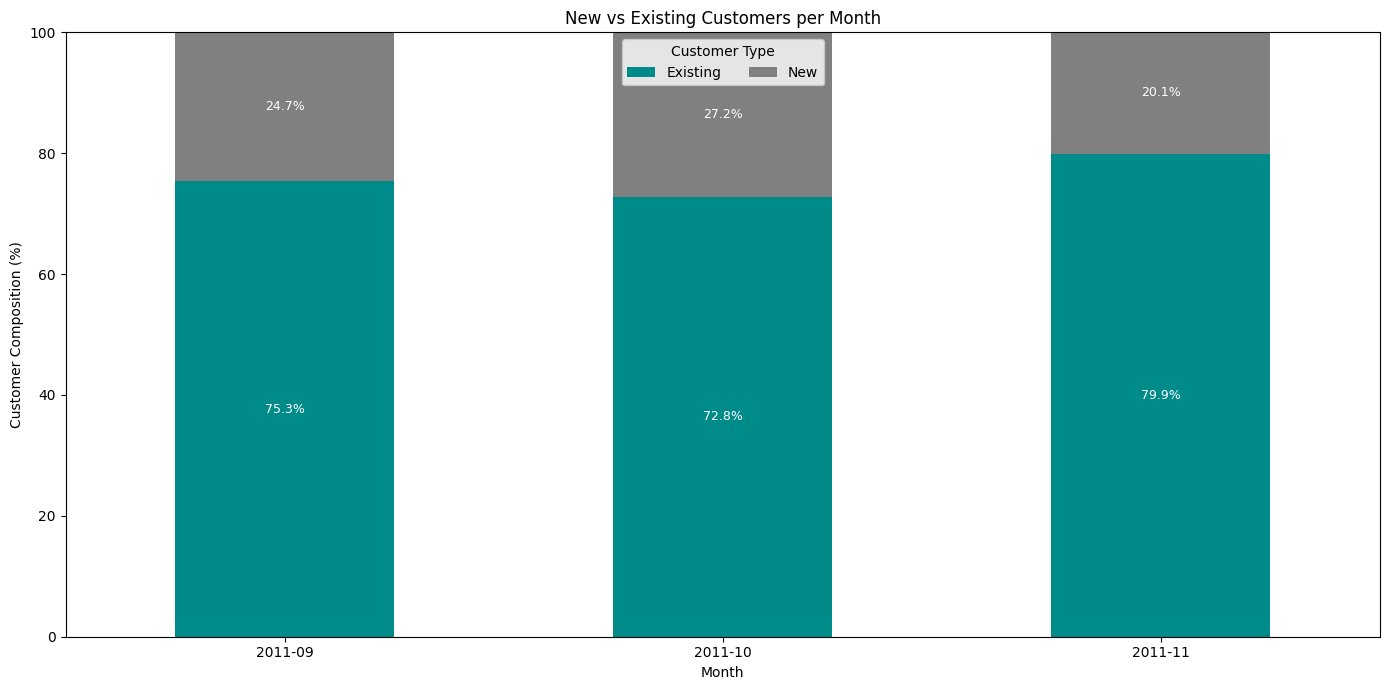

In [ ]:
# Plot stacked bar chart (percentage)
ax = monthly_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 7),
    color=['darkcyan', 'gray']
)

# Annotate bars with percentage labels
for container in ax.containers:
    ax.bar_label(container, labels=[f'{v:.1f}%' for v in container.datavalues],
                 label_type='center', color='white', fontsize=9)

# Format plot
plt.title('New vs Existing Customers per Month')
plt.xlabel('Month')
plt.ylabel('Customer Composition (%)')
plt.xticks(rotation=0)
plt.legend(title='Customer Type', loc='upper center', ncol=2)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

Throughout the analysis period (September to November 2011), existing customers consistently dominated monthly transactions, accounting for more than 76% each month. This highlights a strong customer retention capability and suggests the platform has successfully maintained a loyal user base.

In [ ]:
new_cust_products = seasonal_data[seasonal_data['CustomerType'] == 'New']
new_cust_products.groupby('Description').agg(
    total_qty=('Quantity', 'sum'),
    avg_unit_price=('UnitPrice', 'mean')
).sort_values(by='total_qty', ascending=False).head(10)

,total_qty,avg_unit_price
Description,,
WOODEN STAR CHRISTMAS SCANDINAVIAN,1169,0.330000
PACK OF 72 RETROSPOT CAKE CASES,1042,0.550000
WOODEN HEART CHRISTMAS SCANDINAVIAN,994,0.330580
60 CAKE CASES VINTAGE CHRISTMAS,905,0.550000
VINTAGE SNAP CARDS,842,0.850000
SET OF 20 VINTAGE CHRISTMAS NAPKINS,828,0.850000
WOODEN TREE CHRISTMAS SCANDINAVIAN,805,0.366863
ASSORTED COLOUR BIRD ORNAMENT,780,1.690000
SET OF 60 PANTRY DESIGN CAKE CASES,759,0.550000


### AOV and Revenue Contribution by Customer Type

In [ ]:
# Calculate total revenue for the selected period (Sep–Nov 2011)
total_revenue = seasonal_data['Revenue'].sum()

# Aggregate total revenue and number of unique orders by customer type (New vs Existing)
aov_revenue_contribution = (
    seasonal_data.groupby('CustomerType')
    .agg(
        total_revenue = ('Revenue', 'sum'),
        total_orders = ('InvoiceNo', 'nunique')
    ).reset_index()
)

# Calculate Average Order Value (AOV) and Revenue Contribution Percentage
aov_revenue_contribution['AOV'] = (aov_revenue_contribution['total_revenue'] / aov_revenue_contribution['total_orders']).round(2)
aov_revenue_contribution['Revenue_Contribution_%'] = ((aov_revenue_contribution['total_revenue'] / total_revenue) * 100).round(2)

In [ ]:
aov_revenue_contribution

,CustomerType,total_revenue,total_orders,AOV,Revenue_Contribution_%
0,Existing,1066332.681,4483,237.86,79.83
1,New,269357.711,1096,245.76,20.17


The performance of existing customers demonstrates their significant contribution to the business:

- Revenue Contribution: 79.83% of total revenue.
- Total Orders: 4,483 transactions.
- AOV: £237.86 per order.

This dominance indicates high customer engagement and frequent repeat purchases, making them a critical driver of business sustainability. Moving forward, the business should focus on retention strategies, including loyalty programs, personalized product recommendations, and exclusive offers to maintain and further engage this segment.

In comparison, new customers contributed 20.17% of total revenue, with a slightly higher AOV of £245.76. This may suggest that new customers tend to place larger initial orders, potentially consisting of lower-priced items in higher volumes. However, with only 1,096 total orders, it also indicates lower purchasing frequency and engagement. This presents an opportunity for the business to nurture new customers into loyal ones through strong onboarding, targeted promotions, and retention campaigns.

## RFM Analysis

RFM analysis segments customers based on three behavioral dimensions:

- Recency: How recently the customer made a purchase.

- Frequency: How often they purchased.

- Monetary: How much they spent.

The goal is to classify customers into segments such as:

- Top Customers who are highly valuable and active,

- Potential Customers with growth opportunity,

- At Risk Customers who may require re-engagement,

- Churned customers who left the platform.

RFM is a strong foundation for targeted retention and marketing strategies.

### Filter the Data

In [ ]:
# Filter data within analysis period (September to December 2011)
data_filtered = data_cleaned[(data_cleaned['InvoiceDate'] >= '2011-09-01') & (data_cleaned['InvoiceDate'] < '2012-01-01')]

In [ ]:
data_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 137096 entries, 222031 to 387979
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    137096 non-null  object        
 1   StockCode    137096 non-null  object        
 2   InvoiceDate  137096 non-null  datetime64[ns]
 3   UnitPrice    137096 non-null  float64       
 4   CustomerID   137096 non-null  float64       
 5   Country      137096 non-null  object        
 6   Description  137096 non-null  object        
 7   Quantity     137096 non-null  int64         
 8   Revenue      137096 non-null  float64       
 9   MonthYear    137096 non-null  period[M]     
 10  year         137096 non-null  int32         
 11  month        137096 non-null  int32         
 12  quarter      137096 non-null  int32         
 13  TransMonth   137096 non-null  period[M]     
dtypes: datetime64[ns](1), float64(3), int32(3), int64(1), object(4), period[M](2)
memory

In [ ]:
data_filtered.head()

,InvoiceNo,StockCode,InvoiceDate,UnitPrice,CustomerID,Country,Description,Quantity,Revenue,MonthYear,year,month,quarter,TransMonth
222031,565080,20677,2011-09-01 08:25:00,1.25,13509.0,United Kingdom,PINK POLKADOT BOWL,8,10.0,2011-09,2011,9,3,2011-09
222032,565080,22128,2011-09-01 08:25:00,1.25,13509.0,United Kingdom,PARTY CONES CANDY ASSORTED,24,30.0,2011-09,2011,9,3,2011-09
222033,565082,15060B,2011-09-01 09:15:00,3.75,13305.0,United Kingdom,FAIRY CAKE DESIGN UMBRELLA,8,30.0,2011-09,2011,9,3,2011-09
222035,565082,23245,2011-09-01 09:15:00,4.95,13305.0,United Kingdom,SET OF 3 REGENCY CAKE TINS,4,19.8,2011-09,2011,9,3,2011-09
222037,565083,22212,2011-09-01 09:19:00,2.10,16187.0,United Kingdom,FOUR HOOK WHITE LOVEBIRDS,6,12.6,2011-09,2011,9,3,2011-09


### Calculate RFM

In [ ]:
# Define reference date as the day after the latest transaction
reference_date = data_filtered['InvoiceDate'].max() + dt.timedelta(days = 1)

In [ ]:
reference_date

Timestamp('2011-12-10 12:50:00')

This script calculates the RFM metrics for each customer in the dataset:
- Recency: how recently a customer made a purchase.
- Frequency: how often they made purchases.
- Monetary: how much they spent in total.

RFM is a powerful framework used to segment customers based on their purchasing behavior.

Script Explained:
1. Group by customers: Aggregation is performed per customer (CustomerID), using .groupby().
2. Recency calculation
  - For each customer, take the most recent purchase date (x.max()).
  - Subtract that from a reference_date (usually the day after the latest transaction in the dataset).
  - The result is the number of days since the last purchase — the lower the number, the more recent the customer.
3. Frequency calculation
  - Counts the number of unique invoices for each customer.
  - This represents how frequently a customer has made purchases.
4. Monetary calculation
  - Sums up the total revenue generated by each customer.
  - Represents how much the customer has spent during the observed period.
5. Column renaming
  - Renames the resulting columns for clarity and consistency with the RFM framework.

In [ ]:
# Calculate RFM metrics
rfm = data_filtered.groupby('CustomerID').agg({
    'InvoiceDate' : lambda x: (reference_date - x.max()).days, # Recency
    'InvoiceNo' : 'nunique', # Frequency
    'Revenue' : 'sum' # Monetary
}).reset_index()

# Rename columns
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

In [ ]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12347.0,2,2,894.56
1,12349.0,19,1,924.75
2,12352.0,36,3,591.53
3,12357.0,33,1,1289.35
4,12358.0,2,1,9.36


### RFM Score

This script assigns RFM scores to each customer based on the distribution of their Recency, Frequency, and Monetary values, using quantiles. These scores help classify customers for segmentation purposes.

1. Recency score (R_Score)
  - Recency is divided into 4 quartiles using pd.qcut().
  - Customers with lowest recency (most recent purchase) receive the highest score (4), while those with the highest recency (long time since last purchase) receive the lowest score (1).
  - This reflects that recent customers are more valuable.
2. Frequency score (F_Score)
  - Frequency is ranked first to avoid issues with duplicate values.
  - Then, it’s split into 4 quartiles.
  - Customers who purchased more frequently receive a higher score (4), and less frequent ones receive lower scores.
3. Monetary score
  - Monetary is directly divided into quartiles.
  - Customers with higher total spending are assigned higher scores.

In [ ]:
# Assign RFM scores using quantiles
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4, 3, 2, 1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1, 2, 3, 4]).astype(int)

This script is used to combine individual RFM scores (Recency, Frequency, Monetary) into:
- A concatenated segment code (RFM_Segment)
- A numeric total score (RFM_Score)

These fields are essential for both descriptive segmentation and further analysis.

Script Explained:
1. Create RFM segment
  -  Converts each of the R, F, and M scores to strings.
  - Concatenates them into a 3-digit code.
  
  Example:
  - A customer with R=4, F=2, and M=3 will have RFM_Segment = "423".
  - This code helps quickly identify customer characteristics at a glance.
2. Calculate total RFM score
  - Adds up the individual scores for Recency, Frequency, and Monetary.
  - Resulting RFM_Score ranges from 3 (lowest) to 12 (highest).
  - This score gives a numerical ranking of customer value — the higher the score, the more valuable the customer.

In [ ]:
# Combine scores
rfm['RFM_Segment'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['RFM_Score'] = rfm[['R_Score', 'F_Score', 'M_Score']].sum(axis=1)

In [ ]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,RFM_Score
0,12347.0,2,2,894.56,4,3,4,434,11
1,12349.0,19,1,924.75,3,1,4,314,8
2,12352.0,36,3,591.53,2,3,3,233,8
3,12357.0,33,1,1289.35,2,1,4,214,7
4,12358.0,2,1,9.36,4,1,1,411,6


### RFM Segmentation

In [ ]:
# Define customer segment rules
def segment_label(row):
  if row['Recency'] > 90 and row['Frequency'] == 1 and row['Monetary'] < 50:
    return 'Churned Customers'
  elif row['RFM_Score'] >= 9:
    return 'Top Customers'
  elif row['RFM_Score'] >= 6:
    return 'Potential Customers'
  else:
    return 'At Risk'

rfm['Segment'] = rfm.apply(segment_label, axis=1)

This script defines customer segmentation rules based on RFM (Recency, Frequency, Monetary) analysis. The goal is to classify customers into meaningful behavioral segments that can guide retention and marketing strategies.

A custom function is defined to assign a customer segment label based on RFM values.

Rules explained:
- **Churned Customers**: Customers who haven't purchased in over 90 days, only bought once, and spent less than 50 — indicating they are inactive and low value.
- **Top Customers**: Customers with an overall RFM score ≥ 9 — very recent, frequent, and high-spending.
- **Potential Customers**: RFM score between 6 and 8 — likely to be nurtured into top customers.
- **At Risk**: All remaining customers who do not meet any of the above conditions.

### Visualization

/tmp/ipython-input-75-2667089287.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_counts, x='Segment', y='CustomerCounts',


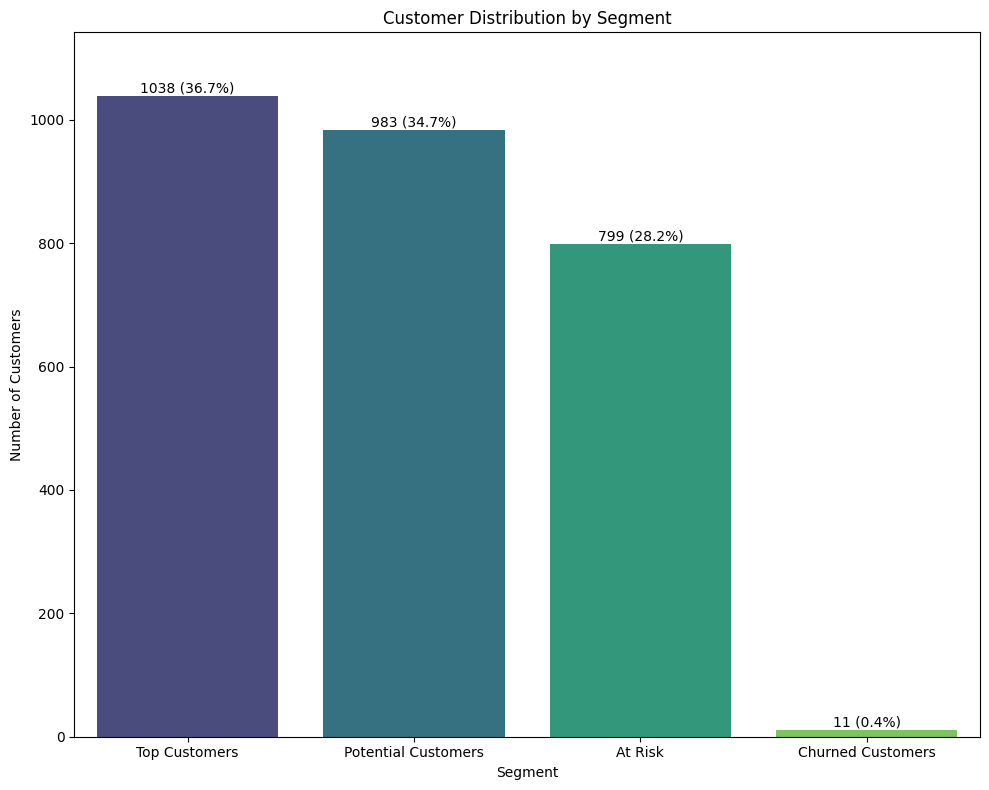

In [ ]:
# Calculate segment distribution
segment_counts = rfm['Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'CustomerCounts']
total_customers = segment_counts['CustomerCounts'].sum()
segment_counts['Percentage'] = (segment_counts['CustomerCounts'] / total_customers * 100).round(2)

# Plot segment distribution
plt.figure(figsize = (10, 8))
sns.barplot(data=segment_counts, x='Segment', y='CustomerCounts',
            palette = "viridis", order = segment_counts.sort_values('CustomerCounts', ascending = False)['Segment'])

# Annotate bars
for i, row in segment_counts.iterrows():
  plt.text(i, row.CustomerCounts + 1,
           f"{row.CustomerCounts} ({row.Percentage:.1f}%)",
           ha = 'center', va = 'bottom', fontsize = 10)

plt.title('Customer Distribution by Segment')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.ylim(0, segment_counts['CustomerCounts'].max() * 1.1)
plt.tight_layout()
plt.show()

The majority of customers fall under the Top Customers and Potential Customers segments, which together account for 71.4% of the customer base. These segments can be classified as loyal customers due to their consistent transaction behavior and contribution levels.

The At Risk segment represents a meaningful portion, consisting of customers who have shown declining activity. This group requires re-engagement strategies to prevent them from transitioning into churned status.

Encouragingly, the Churned customer segment is very small (only 11 transactions), indicating that most customers are likely to return or remain active.

Key considerations:

- Retain loyal customers through exclusive programs, personalized experiences, and proactive communication.
- Reactivate at-risk customers with targeted offers and tailored re-engagement campaigns.

### Revenue Contribution Per Segments

In [ ]:
data_filtered.head()

,InvoiceNo,StockCode,InvoiceDate,UnitPrice,CustomerID,Country,Description,Quantity,Revenue,MonthYear,year,month,quarter,TransMonth
222031,565080,20677,2011-09-01 08:25:00,1.25,13509.0,United Kingdom,PINK POLKADOT BOWL,8,10.0,2011-09,2011,9,3,2011-09
222032,565080,22128,2011-09-01 08:25:00,1.25,13509.0,United Kingdom,PARTY CONES CANDY ASSORTED,24,30.0,2011-09,2011,9,3,2011-09
222033,565082,15060B,2011-09-01 09:15:00,3.75,13305.0,United Kingdom,FAIRY CAKE DESIGN UMBRELLA,8,30.0,2011-09,2011,9,3,2011-09
222035,565082,23245,2011-09-01 09:15:00,4.95,13305.0,United Kingdom,SET OF 3 REGENCY CAKE TINS,4,19.8,2011-09,2011,9,3,2011-09
222037,565083,22212,2011-09-01 09:19:00,2.10,16187.0,United Kingdom,FOUR HOOK WHITE LOVEBIRDS,6,12.6,2011-09,2011,9,3,2011-09


In [ ]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,RFM_Score,Segment
0,12347.0,2,2,894.56,4,3,4,434,11,Top Customers
1,12349.0,19,1,924.75,3,1,4,314,8,Potential Customers
2,12352.0,36,3,591.53,2,3,3,233,8,Potential Customers
3,12357.0,33,1,1289.35,2,1,4,214,7,Potential Customers
4,12358.0,2,1,9.36,4,1,1,411,6,Potential Customers


In [ ]:
# Merge segment info to transactional data
data_with_rfm = data_filtered.merge(rfm[['CustomerID', 'Segment']], on='CustomerID', how='left')

In [ ]:
data_with_rfm.head()

,InvoiceNo,StockCode,InvoiceDate,UnitPrice,CustomerID,Country,Description,Quantity,Revenue,MonthYear,year,month,quarter,TransMonth,Segment
0,565080,20677,2011-09-01 08:25:00,1.25,13509.0,United Kingdom,PINK POLKADOT BOWL,8,10.0,2011-09,2011,9,3,2011-09,Top Customers
1,565080,22128,2011-09-01 08:25:00,1.25,13509.0,United Kingdom,PARTY CONES CANDY ASSORTED,24,30.0,2011-09,2011,9,3,2011-09,Top Customers
2,565082,15060B,2011-09-01 09:15:00,3.75,13305.0,United Kingdom,FAIRY CAKE DESIGN UMBRELLA,8,30.0,2011-09,2011,9,3,2011-09,Top Customers
3,565082,23245,2011-09-01 09:15:00,4.95,13305.0,United Kingdom,SET OF 3 REGENCY CAKE TINS,4,19.8,2011-09,2011,9,3,2011-09,Top Customers
4,565083,22212,2011-09-01 09:19:00,2.10,16187.0,United Kingdom,FOUR HOOK WHITE LOVEBIRDS,6,12.6,2011-09,2011,9,3,2011-09,Top Customers


In [ ]:
data_with_rfm.head()

,InvoiceNo,StockCode,InvoiceDate,UnitPrice,CustomerID,Country,Description,Quantity,Revenue,MonthYear,year,month,quarter,TransMonth,Segment
0,565080,20677,2011-09-01 08:25:00,1.25,13509.0,United Kingdom,PINK POLKADOT BOWL,8,10.0,2011-09,2011,9,3,2011-09,Top Customers
1,565080,22128,2011-09-01 08:25:00,1.25,13509.0,United Kingdom,PARTY CONES CANDY ASSORTED,24,30.0,2011-09,2011,9,3,2011-09,Top Customers
2,565082,15060B,2011-09-01 09:15:00,3.75,13305.0,United Kingdom,FAIRY CAKE DESIGN UMBRELLA,8,30.0,2011-09,2011,9,3,2011-09,Top Customers
3,565082,23245,2011-09-01 09:15:00,4.95,13305.0,United Kingdom,SET OF 3 REGENCY CAKE TINS,4,19.8,2011-09,2011,9,3,2011-09,Top Customers
4,565083,22212,2011-09-01 09:19:00,2.10,16187.0,United Kingdom,FOUR HOOK WHITE LOVEBIRDS,6,12.6,2011-09,2011,9,3,2011-09,Top Customers


This script is designed to evaluate the contribution of each customer segment (from RFM segmentation) in terms of:
- Total revenue generated
- Number of unique orders (invoices)
- Average Order Value (AOV)
- Revenue contribution percentage

This analysis helps in identifying which segments are the most valuable to the business.

Script Explained:
1. Calculate total revenue
  - Sums all revenue values from the dataset to get the overall total revenue.  
  - This value will later be used to calculate the contribution percentage per segment.

2. Aggregate revenue and order count by segment
    - Groups the data by Segment (e.g., Top Customers, At Risk, etc.).
    - For each segment, calculates:
      - **total_revenue**: total revenue generated by customers in that segment.
      - **total_orders**: number of unique invoices (orders) made by that segment.
    - Resulting DataFrame (aov_contribution) gives insight into sales volume and activity level per segment.
3. Calculate AOV and revenue contribution percentage
    - AOV (Average Order Value): How much, on average, each order is worth in that segment.
    - Revenue Contribution %: What portion of the total revenue each segment contributes.

In [ ]:
# Calculate total revenue
total_revenue = data_with_rfm['Revenue'].sum()

# Aggregate revenue and order count by segment
aov_contribution = (
    data_with_rfm.groupby('Segment')
    .agg(
        total_revenue = ('Revenue', 'sum'),
        total_orders = ('InvoiceNo', 'nunique')
    ).reset_index()
)

# Calculate AOV and revenue contribution percentage
aov_contribution['AOV'] = (aov_contribution['total_revenue'] / aov_contribution['total_orders']).round(2)
aov_contribution['Revenue_Contribution_%'] = ((aov_contribution['total_revenue'] / total_revenue) * 100).round(2)

# Display result
aov_contribution.sort_values(by='Revenue_Contribution_%', ascending=False)

,Segment,total_revenue,total_orders,AOV,Revenue_Contribution_%
3,Top Customers,1027309.420,4121,249.29,69.73
2,Potential Customers,313384.030,1322,237.05,21.27
0,At Risk,132178.782,813,162.58,8.97
1,Churned Customers,295.970,11,26.91,0.02


In [ ]:
# Filter At Risk segment for deeper analysis
at_risk_orders = data_with_rfm[data_with_rfm['Segment'] == 'At Risk']

# Aggregate by invoice to observe order patterns
at_risk_invoice_stats = (
    at_risk_orders
    .groupby('InvoiceNo')
    .agg(
        total_quantity=('Quantity', 'sum'),
        avg_unit_price=('UnitPrice', 'mean'),
        order_value=('Revenue', 'sum')
    )
    .reset_index()
)

# Display summary statistics
print(at_risk_invoice_stats.describe())

       total_quantity  avg_unit_price  order_value
count      813.000000      813.000000   813.000000
mean       110.658057        2.141547   162.581528
std         89.525700        0.873787   117.568543
min          1.000000        0.000000     0.000000
25%         45.000000        1.570625    81.600000
50%         88.000000        2.078000   131.850000
75%        155.000000        2.550000   227.290000
max        538.000000        5.950000   615.320000


- Top Customers are the primary revenue drivers, contributing 69.73% of total revenue with the highest AOV of £249.29 and the largest number of orders (4,121).
- Potential Customers contributed 21.27% of revenue, with a competitive AOV of £237.05, though with fewer transactions (1,322 orders).
- The At Risk segment accounts for 8.97% of revenue. Despite fewer orders, their AOV is relatively high (£162.58), likely due to large purchase quantities at lower unit prices, suggesting they might be wholesale or seasonal buyers.

## Cohort Analysis

Cohort analysis tracks customer behavior based on the month of their first purchase.

It reveals:

- How many customers remain active in the following months,

- The month-over-month retention rate for each cohort,

- Which cohort has the best retention.

This analysis is valuable for improving post-purchase engagement strategies, especially during high-season periods.

In [ ]:
# Filter transactions for September to November 2011
data_2011 = data_cleaned[
    (data_cleaned['InvoiceDate'].dt.year == 2011) &
    (data_cleaned['InvoiceDate'].dt.month.isin([9, 10, 11]))
]

This script prepares the dataset for Cohort Analysis, a method used to track customer behavior over time based on their first purchase month. It helps evaluate retention, engagement, and lifetime value of customer cohorts.

1. Extract transaction month
  - Converts the transaction date (InvoiceDate) to a monthly period (e.g., 2011-06), stored as InvoiceMonth.
  - Used to group transactions by month (rather than specific day).
2. Identify cohort month (first purchase month)
  - For each CustomerID, finds the earliest purchase date (first invoice).
  - Converts that date to a monthly period, stored as CohortMonth.
  - This marks the month when the customer first entered the system — defining their cohort group.
3. Calculate cohort index
  - Computes how many months have passed since the customer's first purchase.
  
  Example:
  - If a customer’s CohortMonth is Sep 2011 and the transaction is in Oct 2011, CohortIndex = 3.
  - This shows how long a customer has been active since joining.

In [ ]:
# Extract transaction month from InvoiceDate
data_2011['InvoiceMonth'] = data_2011['InvoiceDate'].dt.to_period('M')

# Identify the cohort month (first purchase month) for each customer
data_2011['CohortMonth'] = data_2011.groupby('CustomerID')['InvoiceDate'].transform('min').dt.to_period('M')

# Calculate CohortIndex secara vektorized
data_2011['CohortIndex'] = (data_2011['InvoiceMonth'].dt.year - data_2011['CohortMonth'].dt.year) * 12 + (data_2011['InvoiceMonth'].dt.month - data_2011['CohortMonth'].dt.month)

/tmp/ipython-input-84-340875056.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_2011['InvoiceMonth'] = data_2011['InvoiceDate'].dt.to_period('M')
/tmp/ipython-input-84-340875056.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_2011['CohortMonth'] = data_2011.groupby('CustomerID')['InvoiceDate'].transform('min').dt.to_period('M')
/tmp/ipython-input-84-340875056.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_ind

This script calculates and reshapes data to create a cohort matrix showing how many unique customers from each cohort continue to make purchases over time. This is the core step in customer retention analysis.

1. Calculate unique customers per cohort and month
  - Groups the dataset by:
      - **CohortMonth**: the month when the customer made their first purchase.
      - **CohortIndex**: number of months since the customer joined (0 = first month).
  - Then, it counts the number of unique customers (nunique()) for each combination of cohort and month.
2. Reshape into a cohort table
  - Converts the long-form data (cohort_data) into a wide-form table (matrix) using pivot().
  - Rows = **CohortMonth**: each row is a cohort group (based on first purchase month).
  - Columns = **CohortIndex**: each column represents months since first purchase.
  - Values = number of active unique customers.

In [ ]:
# Calculate the number of unique customers per CohortMonth and CohortIndex
cohort_data = data_2011.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'].nunique().reset_index()

# Reshape the data to a matrix where rows = cohort month, columns = months since first purchase
cohort_pivot = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='CustomerID')

This script calculates monthly retention rates for each customer cohort by dividing the number of active customers each month by the size of the original cohort. It helps to evaluate customer retention performance over time.

1. Get initial cohort size
  - Extracts the first column of the **cohort_pivot** table, which represents month 0 (i.e., the number of customers in each cohort when they first joined).
  - This will be used as the denominator for calculating retention rate.
2. Calculate retention rate
  - Divides each row of the **cohort_pivot** matrix by the corresponding value in cohort_size.
  - This gives a matrix where each cell is a proportion of customers retained in that month since the first purchase.
  - The result is rounded to 3 decimal places for clarity.

In [ ]:
# Calculate retention by dividing each cell by the size of the cohort (first column)
cohort_size = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_size, axis=0).round(3)

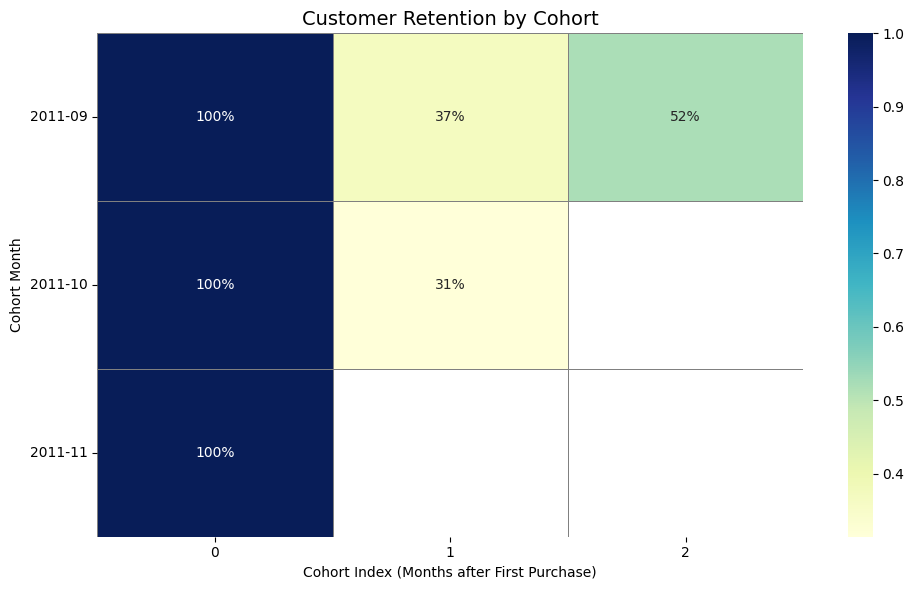

In [ ]:
# Visualize retention with a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    retention,
    annot=True, fmt=".0%", cmap="YlGnBu",
    linewidths=0.5, linecolor='gray'
)

# Customize the plot
plt.title('Customer Retention by Cohort', fontsize=14)
plt.xlabel('Cohort Index (Months after First Purchase)')
plt.ylabel('Cohort Month')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

The cohort analysis reveals that customers who made their first purchase in September 2011 showed a relatively strong retention rate. 37% of them returned in the second month, and retention increased further to 52% in the third month—a positive trend indicating increasing engagement as the holiday season approaches.

For the October 2011 cohort, 31% of customers returned in the following month, slightly lower than the September cohort but still demonstrating decent retention performance.

These retention patterns support the assumption that customer activity tends to rise closer to the Christmas season, reinforcing the seasonal nature of purchasing behavior.

## top 5 product by Period

This analysis focuses on identifying the best-selling products from September to December.

Its importance includes:

- Highlighting seasonal products that drive revenue,

- Informing promotional strategies during holiday campaigns,

- Supporting demand forecasting and inventory planning.

In [ ]:
data_filtered

,InvoiceNo,StockCode,InvoiceDate,UnitPrice,CustomerID,Country,Description,Quantity,Revenue,MonthYear,year,month,quarter,TransMonth
222031,565080,20677,2011-09-01 08:25:00,1.25,13509.0,United Kingdom,PINK POLKADOT BOWL,8,10.0,2011-09,2011,9,3,2011-09
222032,565080,22128,2011-09-01 08:25:00,1.25,13509.0,United Kingdom,PARTY CONES CANDY ASSORTED,24,30.0,2011-09,2011,9,3,2011-09
222033,565082,15060B,2011-09-01 09:15:00,3.75,13305.0,United Kingdom,FAIRY CAKE DESIGN UMBRELLA,8,30.0,2011-09,2011,9,3,2011-09
222035,565082,23245,2011-09-01 09:15:00,4.95,13305.0,United Kingdom,SET OF 3 REGENCY CAKE TINS,4,19.8,2011-09,2011,9,3,2011-09
222037,565083,22212,2011-09-01 09:19:00,2.10,16187.0,United Kingdom,FOUR HOOK WHITE LOVEBIRDS,6,12.6,2011-09,2011,9,3,2011-09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
387975,581587,22730,2011-12-09 12:50:00,3.75,12680.0,France,ALARM CLOCK BAKELIKE IVORY,4,15.0,2011-12,2011,12,4,2011-12
387976,581587,22899,2011-12-09 12:50:00,2.10,12680.0,France,CHILDREN'S APRON DOLLY GIRL,6,12.6,2011-12,2011,12,4,2011-12
387977,581587,23254,2011-12-09 12:50:00,4.15,12680.0,France,CHILDRENS CUTLERY DOLLY GIRL,4,16.6,2011-12,2011,12,4,2011-12
387978,581587,23255,2011-12-09 12:50:00,4.15,12680.0,France,CHILDRENS CUTLERY CIRCUS PARADE,4,16.6,2011-12,2011,12,4,2011-12


In [ ]:
# Calculate total quantity sold per product per month
top5_sep_dec = (
    data_filtered.groupby(['MonthYear', 'Description'])
    .agg(total_quantity = ('Quantity', 'sum'))
    .reset_index()
    .sort_values(by='total_quantity', ascending=False)
    .head(5)
)

In [ ]:
# Aggregate monthly total quantity for each product
monthly_top_products = (
    data_filtered
    .groupby(['MonthYear', 'Description'])
    .agg(total_quantity=('Quantity', 'sum'))
    .reset_index()
)

# Sort by MonthYear and total quantity, then select top 5 per month
monthly_top5 = (
    monthly_top_products
    .sort_values(['MonthYear', 'total_quantity'], ascending=[True, False])
    .groupby('MonthYear')
    .head(5)
    .reset_index(drop=True)
)

In [ ]:
monthly_top5

,MonthYear,Description,total_quantity
0,2011-09,PACK OF 72 RETROSPOT CAKE CASES,1458
1,2011-09,60 CAKE CASES VINTAGE CHRISTMAS,1365
2,2011-09,SET OF 60 PANTRY DESIGN CAKE CASES,1326
3,2011-09,LUNCH BAG VINTAGE DOILY,1157
4,2011-09,LUNCH BAG RED RETROSPOT,1024
5,2011-10,WOODEN STAR CHRISTMAS SCANDINAVIAN,1793
6,2011-10,WOODEN HEART CHRISTMAS SCANDINAVIAN,1735
7,2011-10,60 CAKE CASES VINTAGE CHRISTMAS,1470
8,2011-10,PACK OF 72 RETROSPOT CAKE CASES,1310
9,2011-10,WOODEN TREE CHRISTMAS SCANDINAVIAN,1245


/tmp/ipython-input-92-1011754888.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


<Figure size 1200x1000 with 0 Axes>

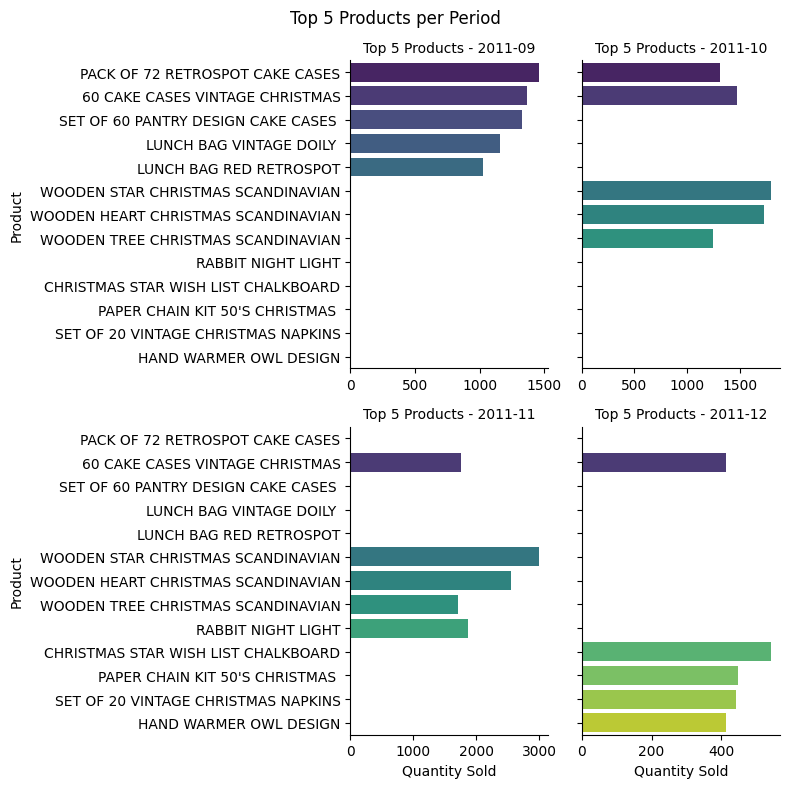

In [ ]:
# Visualize monthly top 5 products
plt.figure(figsize=(12, 10))
g = sns.catplot(
    data=monthly_top5,
    kind='bar',
    y='Description',
    x='total_quantity',
    col='MonthYear',
    col_wrap=2,
    height=4,
    sharex=False,
    palette='viridis'
)

g.set_titles("Top 5 Products - {col_name}")
g.set_axis_labels("Quantity Sold", "Product")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Top 5 Products per Period')
g.tight_layout()
plt.show()

The top-selling products by month show a clear trend: Christmas-themed accessories and decorations dominate the list. Examples include:

- Christmas Scandinavian decorations
- Themed gift sets
- Paper chains and napkins with holiday designs

This supports the hypothesis that holiday seasons significantly influence purchasing behavior, particularly for themed or seasonal products.

## Product by RFM Segment

This analysis identifies the most purchased products for each RFM customer segment.

It helps to:

- Understand product preferences of loyal vs at-risk customers,

- Customize product recommendations or campaigns per segment,

- Plan effective bundling strategies.

In [ ]:
# Prepare data with segment and product description
product_by_segment = data_with_rfm[['Segment', 'Description', 'Quantity']]

In [ ]:
# Aggregate total quantity per product per segment
product_counts = (
    product_by_segment.groupby(['Segment', 'Description']).agg(
        total_quantity = ('Quantity', 'sum')
    ).reset_index()
)

In [ ]:
# Sort and select top 5 products for each segment
top5_products = (
    product_counts.sort_values(['Segment', 'total_quantity'], ascending = [True, False]).groupby(
        'Segment').head(5).reset_index(drop=True)
)

/tmp/ipython-input-97-3888373109.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


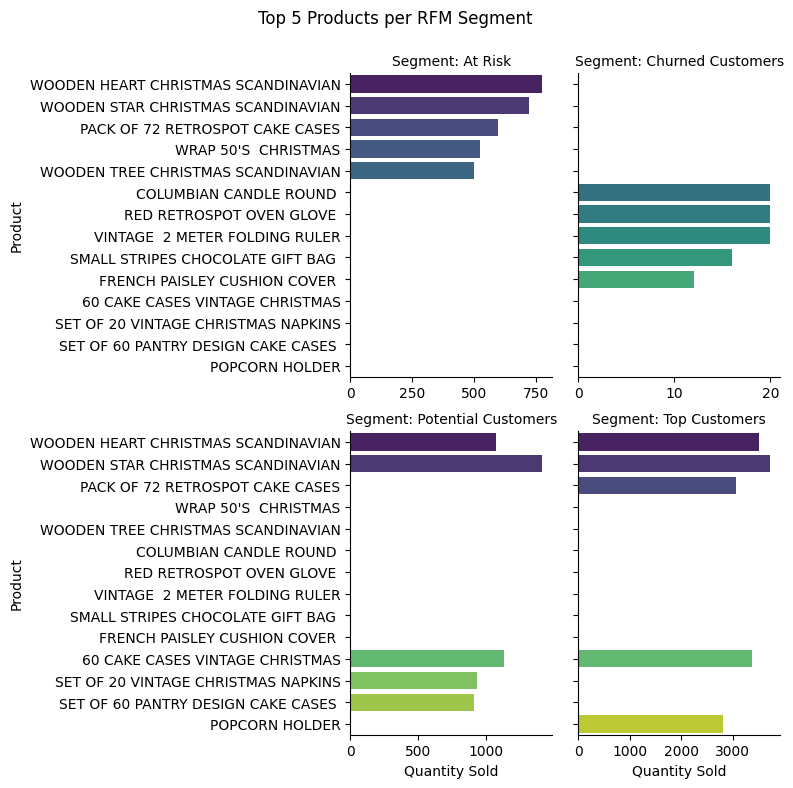

In [ ]:
# Visualize top 5 products per segment
g = sns.catplot(
    data=top5_products,
    kind='bar',
    x='total_quantity',
    y='Description',
    col='Segment',
    col_wrap=2,
    height=4,
    sharex=False,
    palette='viridis'
)

g.set_titles("Segment: {col_name}")
g.set_axis_labels("Quantity Sold", "Product")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Top 5 Products per RFM Segment')
plt.show()

When broken down by RFM customer segments, the product preference remains consistent. Across all segments—Top Customers, Potential, At Risk, and Churned—the best-selling items are:

- Christmas-themed decorations
- Gift items
- Seasonal accessories

This consistency indicates that customer needs across segments are highly seasonal, presenting an opportunity to implement seasonal targeting strategies and tailor marketing efforts based on calendar-driven demand.

# Clarifying Questions, Assumptions, and Caveats

## Clarifying Questions:


*   Are all products with a price of £0 considered promotional or bonus items?
*   Were there any discount or promotional campaigns during peak order periods, such as November?

## Assumptions:
- Duplicate rows with the same **InvoiceNo**, **StockCode**, and **CustomerID** are consolidated:
  1.    If the **Quantity** values differ, they are summed as separate purchases by the same customer.
  2.   If the **Quantity** values are the same and appear more than once, they are assumed to be duplicate entries and are also combined.

- All transactions are assumed to be conducted online, as there is no evidence of physical store presence in the dataset.

## Caveats:
- A large portion of records have null **CustomerID**, limiting customer-level analysis.
- The dataset does not include any information on operational costs or product returns. As a result, all revenue-related insights are based solely on gross revenue and do not reflect actual profitability.
- December 2011 data appears to be incomplete and may not represent full-month activity.